# Baseline

These tables contain multiple records for a single client.
Before merging with `application_train` or `application_test`, it is necessary
to engineer features and aggregate the tables to a single row per `SK_ID_CURR`.

Standard numerical features are aggregated in the same way (median, max).
Categorical features are transformed into separate COUNT and SHARE features.
Special features are handled manually based on their meaning.

## Import all

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from narwhals import Categorical
from narwhals.selectors import categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, precision_score, recall_score, ConfusionMatrixDisplay, confusion_matrix, roc_curve
from lightgbm.callback import early_stopping, log_evaluation

import lightgbm as lgb

In [2]:
import gc
import ctypes

def free_memory():
    gc.collect()
    try:
        ctypes.CDLL("libc.so.6").malloc_trim(0)
    except OSError:
        pass

In [3]:
path_to_data = "/home/usl/PycharmProjects/home-credit-default-risk/data/raw/home-credit-default-risk/"
# path_to_data = "/content/drive/MyDrive/Home_Credit_data/"

application_train_df = pd.read_csv(path_to_data+"application_train.csv")
application_test_df = pd.read_csv(path_to_data+"application_test.csv")
# bureau_df = pd.read_csv(path_to_data+"bureau.csv")
# bureau_balance_df = pd.read_csv(path_to_data+"bureau_balance.csv")
# credit_card_balance_df = pd.read_csv(path_to_data+"credit_card_balance.csv")
home_credit_columns_description_df = pd.read_csv(path_to_data+"HomeCredit_columns_description.csv", encoding="cp1252")
# installments_payments_df = pd.read_csv(path_to_data+"installments_payments.csv")
# POS_CASH_balance_df = pd.read_csv(path_to_data+"POS_CASH_balance.csv")
# previous_application_df = pd.read_csv(path_to_data+"previous_application.csv")

# Feature engineering

## Main function for numerical and categorical features

### Numerical features: main function

In [4]:
agg_func = ["median", "max"]
def agg_numerical_features(df, id_col, numerical_cols, prefix):
    result = (df.groupby(id_col)[numerical_cols].agg(agg_func))
    result.columns = [prefix + "_" + col + "_" + func for col, func in result.columns]
    return result.astype("float32")

In [5]:
def agg_window_numerical_features(df, id_col, numerical_cols, prefix, sort_col, window_sizes=(3, 5, 10), agg_funcs=("median", "max")):
    sorted_df = df.sort_values(by=[id_col, sort_col])
    result_blocks = []

    for window_size in window_sizes:
        last_n_rows = (sorted_df.groupby(id_col, sort=False).tail(window_size))
        window_features = (last_n_rows.groupby(id_col, sort=False)[numerical_cols].agg(agg_funcs))
        window_features.columns = [f"{prefix}_LAST_{window_size}_{column}_{agg}" for column, agg in window_features.columns]
        record_count = (last_n_rows.groupby(id_col, sort=False).size().rename(f"{prefix}_LAST_{window_size}_RECORD_COUNT"))
        window_features = pd.concat([window_features, record_count], axis=1)
        result_blocks.append(window_features)
    result = pd.concat(result_blocks, axis=1).astype("float32")
    return result

In [6]:
def agg_time_window_numerical_features(df, id_col, time_col, numerical_cols, prefix, window_sizes=(3, 6, 12), unit="M", agg_funcs=("mean", "median", "max")):
    result_blocks = []
    last_period = df[time_col].max()
    for window_size in window_sizes:

        first_period = last_period - (window_size - 1)
        mask = ((df[time_col] >= first_period) & (df[time_col] <= last_period))
        window_df = df.loc[mask, [id_col] + numerical_cols]
        window_features = (window_df.groupby(id_col, sort=False)[numerical_cols].agg(agg_funcs))
        window_features.columns = [f"{prefix}_LAST_{window_size}{unit}_{column}_{agg}" for column, agg in window_features.columns]
        record_count = (window_df.groupby(id_col, sort=False).size().rename(f"{prefix}_LAST_{window_size}{unit}_RECORD_COUNT"))
        window_features = pd.concat([window_features, record_count], axis=1)
        window_features = window_features.astype("float32")
        result_blocks.append(window_features)
    result = pd.concat(result_blocks, axis=1)

    return result

For example:

In [ ]:
#numerical_cols_bureau_df = ["AMT_CREDIT_MAX_OVERDUE", "AMT_CREDIT_SUM", "AMT_CREDIT_SUM_DEBT","AMT_CREDIT_SUM_LIMIT", "AMT_CREDIT_SUM_OVERDUE", "AMT_ANNUITY"]

In [ ]:
#bureau_num = make_numerical_features(bureau_df, "SK_ID_CURR", numerical_cols_bureau_df, "BUREAU")
#bureau_num

## Categorical features: main function

In [ ]:
def agg_categorical_features(df, id_col, categorical_cols, prefix):
        temp = df[[id_col] + categorical_cols].copy()
        temp[categorical_cols] = (temp[categorical_cols].fillna("Missing"))
        dummies = pd.get_dummies(temp[categorical_cols], prefix = [prefix + "_" + col for col in categorical_cols], dtype = np.uint8)
        dummies[id_col] = temp[id_col]
        counts = (dummies.groupby(id_col).sum().astype("float32"))
        shares = (dummies.groupby(id_col).mean().astype("float32"))
        counts.columns = [col + "_COUNT" for col in counts.columns]
        shares.columns = [col + "_SHARE" for col in shares.columns]
        result = pd.concat([counts, shares], axis=1)

        return result

For example:

In [ ]:
#categorical_cols_bureau_df = ["CREDIT_ACTIVE", "CREDIT_CURRENCY", "CREDIT_TYPE"]

In [ ]:
#bureau_cat = make_categorical_features(bureau_df, "SK_ID_CURR", categorical_cols_bureau_df, "BUREAU")
#bureau_cat

## Main function for tables to client:

In [ ]:
def add_contract_feat_to_client(df, prefix):
    sum_cols = [col for col in df.columns if col.endswith("_COUNT") or col.endswith("_SUM")]
    other_cols = [col for col in df.columns if col not in ["SK_ID_PREV", "SK_ID_CURR"] and col not in sum_cols]
    tables = []

    if len(sum_cols) > 0:
        client_sum = (df.groupby("SK_ID_CURR")[sum_cols].sum())
        tables.append(client_sum)

    if len(other_cols) > 0:
        client_other = (df.groupby("SK_ID_CURR")[other_cols].agg(["median", "max"]))

        client_other.columns = [col + "_" + func for col, func in client_other.columns]
        tables.append(client_other)

    contract_count = (df.groupby("SK_ID_CURR")["SK_ID_PREV"].nunique().rename(prefix + "_CONTRACT_WITH_HISTORY_COUNT").to_frame())
    tables.append(contract_count)
    result = pd.concat(tables, axis=1)
    return result

## Bureau_df

In [ ]:
bureau_df = pd.read_csv(path_to_data + "bureau.csv")

In [ ]:
bureau_df.info(show_counts=True)

In [ ]:
bureau_description = home_credit_columns_description_df[home_credit_columns_description_df["Table"].astype(str).str.contains("bureau.csv", case = False, na=False)]
display(bureau_description[["Row", "Description"]])

Wi can split all features into numerical, categorical and special ones.

In [ ]:
categorical_cols_bureau_df = ["CREDIT_ACTIVE", "CREDIT_CURRENCY", "CREDIT_TYPE"]
numerical_cols_bureau_df = ["AMT_CREDIT_MAX_OVERDUE", "AMT_CREDIT_SUM", "AMT_CREDIT_SUM_DEBT","AMT_CREDIT_SUM_LIMIT", "AMT_CREDIT_SUM_OVERDUE", "AMT_ANNUITY"]
special_cols_bureau_df = ["SK_ID_CURR", "SK_ID_BUREAU", "DAYS_CREDIT", "DAYS_CREDIT_ENDDATE","DAYS_ENDDATE_FACT", "DAYS_CREDIT_UPDATE", "CREDIT_DAY_OVERDUE", "CNT_CREDIT_PROLONG"]

In [ ]:
print("SPECIAL:", special_cols_bureau_df)
print("\nCATEGORICAL:", categorical_cols_bureau_df)
print("\nNUMERICAL:", numerical_cols_bureau_df)

### Numerical

In [ ]:
bureau_num = agg_numerical_features(bureau_df, "SK_ID_CURR", numerical_cols_bureau_df, "BUREAU")
bureau_num

In [ ]:
bureau_df["DEBT_TO_CREDIT"] = (bureau_df["AMT_CREDIT_SUM_DEBT"] / bureau_df["AMT_CREDIT_SUM"].replace(0, np.nan))
bureau_df["OVERDUE_TO_CREDIT"] = (bureau_df["AMT_CREDIT_SUM_OVERDUE"] / bureau_df["AMT_CREDIT_SUM"].replace(0, np.nan))

In [ ]:
bureau_window_cols = (numerical_cols_bureau_df + ["CREDIT_DAY_OVERDUE", "CNT_CREDIT_PROLONG", "DEBT_TO_CREDIT", "OVERDUE_TO_CREDIT"])
bureau_num_window = agg_window_numerical_features(
    df=bureau_df,
    id_col="SK_ID_CURR",
    numerical_cols=bureau_window_cols,
    prefix="BUREAU",
    sort_col="DAYS_CREDIT",
    window_sizes=(3, 5, 10)
)
bureau_num_window.head()

In [ ]:
bureau_last = (bureau_df.sort_values(["SK_ID_CURR", "DAYS_CREDIT"]).groupby("SK_ID_CURR").tail(1).set_index("SK_ID_CURR")[numerical_cols_bureau_df + ["DAYS_CREDIT"]].copy())
bureau_last.columns = ["BUREAU_LAST_" + col for col in bureau_last.columns]

### Trend

In [ ]:
bureau_trend = pd.DataFrame(index=bureau_num_window.index)

In [ ]:
for col in numerical_cols_bureau_df:
    bureau_trend["BUREAU_TREND_3_10_" + col] = (bureau_num_window["BUREAU_LAST_3_" + col + "_median"] - bureau_num_window["BUREAU_LAST_10_" + col + "_median"])

In [ ]:
for col in numerical_cols_bureau_df:
    bureau_trend["BUREAU_TREND_5_10_" + col] = (bureau_num_window["BUREAU_LAST_5_" + col + "_median"] - bureau_num_window["BUREAU_LAST_10_" + col + "_median"])

### Categorical

In [ ]:
bureau_cat = agg_categorical_features(bureau_df, "SK_ID_CURR", categorical_cols_bureau_df, "BUREAU")
bureau_cat

### Special

We can calculate the count of credits:

In [ ]:
bureau_credit_count = (bureau_df.groupby("SK_ID_CURR")["SK_ID_BUREAU"].count().rename("BUREAU_CREDIT_COUNT"))
bureau_credit_count.shape

In [ ]:
#bureau_df["CREDIT_ACTIVE"].value_counts(dropna=False)

And we can check whether there is active credit or not:

In [ ]:
bureau_df["IS_ACTIVE_CREDIT"] = (bureau_df["CREDIT_ACTIVE"] == "Active").astype(int)
bureau_active = (bureau_df.groupby("SK_ID_CURR").agg(BUREAU_ACTIVE_COUNT = ("IS_ACTIVE_CREDIT", "sum"), BUREAU_ACTIVE_SHARE = ("IS_ACTIVE_CREDIT", "mean")))
bureau_active.head()

We can check how many days of credit are available:

In [ ]:
bureau_df["DAYS_CREDIT"].describe()


max indicates how recently the last loan was taken out,
min indicates how far back the credit history goes,
median typical age of the client's loans

In [ ]:
bureau_days_credit = (bureau_df.groupby("SK_ID_CURR").agg(BUREAU_MOST_RECENT_CREDIT_DAYS = ("DAYS_CREDIT", "max"), BUREAU_OLDEST_CREDIT_DAYS = ("DAYS_CREDIT", "min"), BUREAU_MEDIAN_CREDIT_DAYS = ("DAYS_CREDIT", "median")))
bureau_days_credit.head()

We can obtain the length of the client's credit history:

In [ ]:
bureau_days_credit["BUREAU_CREDIT_HISTORY_LENGTH"] = (bureau_days_credit["BUREAU_MOST_RECENT_CREDIT_DAYS"] - bureau_days_credit["BUREAU_OLDEST_CREDIT_DAYS"])
bureau_days_credit

In [ ]:
#bureau_df["CREDIT_DAY_OVERDUE"].describe()

On this part we look at overdue:

In [ ]:
bureau_df["IS_DAY_OVERDUE"] = (bureau_df["CREDIT_DAY_OVERDUE"] > 0).astype(int)

In [ ]:
bureau_overdue = (bureau_df.groupby("SK_ID_CURR").agg(BUREAU_MAX_DAYS_OVERDUE=("CREDIT_DAY_OVERDUE", "max"), BUREAU_OVERDUE_CREDIT_COUNT=("IS_DAY_OVERDUE", "sum"), BUREAU_OVERDUE_CREDIT_SHARE=("IS_DAY_OVERDUE", "mean")))
bureau_overdue.head(20)

In [ ]:
# print("Доля записей с просрочкой:", (bureau_df["CREDIT_DAY_OVERDUE"] > 0).mean())
# print("Количество записей с просрочкой:", (bureau_df["CREDIT_DAY_OVERDUE"] > 0).sum())

In [ ]:
#(bureau_overdue["BUREAU_OVERDUE_CREDIT_COUNT"] > 0).mean()

In [ ]:
# temp = application_train_df[["SK_ID_CURR", "TARGET"]].merge(bureau_overdue, on="SK_ID_CURR", how="left")
# temp["HAS_BUREAU_OVERDUE"] = (temp["BUREAU_OVERDUE_CREDIT_COUNT"].fillna(0) > 0).astype(int)
# temp.groupby("HAS_BUREAU_OVERDUE")["TARGET"].agg(["count", "mean"])

We will collect data on the loan extension:

In [ ]:
bureau_df["IS_PROLONGED"] = (bureau_df["CNT_CREDIT_PROLONG"] > 0).astype(int)
bureau_prolong = bureau_df.groupby("SK_ID_CURR").agg(BUREAU_TOTAL_PROLONG = ("CNT_CREDIT_PROLONG", "sum"), BUREAU_MAX_PROLONG = ("CNT_CREDIT_PROLONG", "max"), BUREAU_PROLONG_SHARE = ("IS_PROLONGED", "mean"))
bureau_prolong

We will collect data of the days credit end data:

In [ ]:
bureau_df["ENDS_AFTER_APPLICATION"] = np.where(bureau_df["DAYS_CREDIT_ENDDATE"].isna(), np.nan, (bureau_df["DAYS_CREDIT_ENDDATE"] > 0).astype(int))
bureau_credit_enddate = bureau_df.groupby("SK_ID_CURR").agg(BUREAU_LAST_PLANNED_ENDDATE=("DAYS_CREDIT_ENDDATE", "max"), BUREAU_MEAN_PLANNED_ENDDATE=("DAYS_CREDIT_ENDDATE", "mean"), BUREAU_ENDS_AFTER_APPL_SHARE=("ENDS_AFTER_APPLICATION", "mean"))
bureau_credit_enddate

In [ ]:
bureau_fact_enddate = (bureau_df.groupby("SK_ID_CURR").agg(BUREAU_LAST_FACT_ENDDATE = ("DAYS_ENDDATE_FACT", "max"), BUREAU_MEAN_FACT_ENDDATE = ("DAYS_ENDDATE_FACT", "mean")))
bureau_fact_enddate

And we will find the difference between the planned (fact) and actual dates:

In [ ]:
bureau_df["ENDDATE_DIFF"] = bureau_df["DAYS_ENDDATE_FACT"] - bureau_df["DAYS_CREDIT_ENDDATE"]
bureau_enddate_diff = (bureau_df.groupby("SK_ID_CURR").agg(BUREAU_MEDIAN_DIFF_ENDDATE = ("ENDDATE_DIFF", "median"), BUREAU_MAX_DIFF_ENDDATE = ("ENDDATE_DIFF", "max")))
bureau_enddate_diff

In [ ]:
bureau_update = (bureau_df.groupby("SK_ID_CURR").agg(BUREAU_LAST_UPDATE_DAYS = ("DAYS_CREDIT_UPDATE", "max"), BUREAU_MEAN_UPDATE_DAYS = ("DAYS_CREDIT_UPDATE", "mean")))
bureau_update

We now synthesize the ratio of monetary quantities to others:

In [ ]:
bureau_ratios = bureau_df.groupby("SK_ID_CURR").agg(BUREAU_MEDIAN_DEBT_RATIO = ("DEBT_TO_CREDIT", "median"), BUREAU_MAX_DEBT_RATIO = ("DEBT_TO_CREDIT", "max"), BUREAU_MEDIAN_OVERDUE_RATIO = ("OVERDUE_TO_CREDIT", "median"), BUREAU_MAX_OVERDUE_RATIO = ("OVERDUE_TO_CREDIT", "max"))
bureau_ratios

Finally, we will gather all the special features:

In [ ]:
bureau_special = pd.concat(
    [
        bureau_credit_count,
        bureau_active,
        bureau_days_credit,
        bureau_overdue,
        bureau_prolong,
        bureau_credit_enddate,
        bureau_fact_enddate,
        bureau_enddate_diff,
        bureau_update,
        bureau_ratios
    ],
    axis=1
)
bureau_special.head()

All features for bureau_df:

In [ ]:
bureau_features = pd.concat([
    bureau_num,
    bureau_num_window,
    bureau_last,
    # bureau_trend,
    bureau_cat,
    bureau_special
], axis=1)
bureau_features.head()

In [ ]:
# print("Размер:", bureau_features.shape)
# print("Уникальный SK_ID_CURR:", bureau_features.index.is_unique)
# print("Количество клиентов:", bureau_features.shape[0])

## Bureau_balance_df

In [ ]:
bureau_balance_df = pd.read_csv(path_to_data+"bureau_balance.csv")

In [ ]:
bureau_balance_df.info(show_counts=True)
bureau_balance_df.shape

In [ ]:
home_credit_columns_description_df = pd.read_csv(path_to_data+"HomeCredit_columns_description.csv", encoding="cp1252")
bureau_balance_description = home_credit_columns_description_df[home_credit_columns_description_df["Table"].astype(str).str.contains("bureau_balance.csv", case = False, na=False)]
display(bureau_balance_description[["Row", "Description"]])

In [ ]:
categorical_cols_bureau_balance_df = ["STATUS"]
numerical_cols_bureau_balance_df = []
special_cols_bureau_balance_df = ["SK_ID_BUREAU", "MONTHS_BALANCE"]

In [ ]:
print("SPECIAL:", special_cols_bureau_balance_df)
print("\nCATEGORICAL:", categorical_cols_bureau_balance_df)
print("\nNUMERICAL:", numerical_cols_bureau_balance_df)

### Categorical

In [ ]:
bureau_balance_df["STATUS"].value_counts(dropna=False)

In [ ]:
bureau_balance_df["IS_BB_OVERDUE"] = bureau_balance_df["STATUS"].isin(["1", "2", "3", "4", "5"]).astype(int)

In [ ]:
bureau_balance_df["IS_BB_OVERDUE"].value_counts()

In [ ]:
bureau_balance_df["IS_BB_OVERDUE"].mean()

We can add hard overdue:

In [ ]:
bureau_balance_df["IS_BB_SEVERE_OVERDUE"] = bureau_balance_df["STATUS"].isin(["3", "4", "5"]).astype(int)

In [ ]:
bureau_to_client = (bureau_df.drop_duplicates("SK_ID_BUREAU").set_index("SK_ID_BUREAU")["SK_ID_CURR"])
bureau_balance_df["SK_ID_CURR"] = (bureau_balance_df["SK_ID_BUREAU"].map(bureau_to_client))

In [ ]:
status_to_number = {
    "0": 0,
    "1": 1,
    "2": 2,
    "3": 3,
    "4": 4,
    "5": 5,
    "C": 0,
    "X": np.nan
}

bureau_balance_df["BB_STATUS_LEVEL"] = (bureau_balance_df["STATUS"].map(status_to_number).astype("float32"))

In [ ]:
bb_window_features = agg_time_window_numerical_features(
    df=bureau_balance_df,
    id_col="SK_ID_CURR",
    time_col="MONTHS_BALANCE",
    numerical_cols=["IS_BB_OVERDUE", "IS_BB_SEVERE_OVERDUE", "BB_STATUS_LEVEL"],
    prefix="BB",
    window_sizes=(3, 6, 12),
    unit="M"
)

bb_window_features.head()

In [ ]:
bureau_balance_cat = agg_categorical_features(bureau_balance_df, "SK_ID_BUREAU", categorical_cols_bureau_balance_df, "BB")
bureau_balance_cat

### Special

In [ ]:
bureau_balance_df["MONTHS_BALANCE"].value_counts(dropna=False)

In [ ]:
bureau_balance_special = (bureau_balance_df.groupby("SK_ID_BUREAU").agg(BB_MONTH_COUNT=("MONTHS_BALANCE","count"),
BB_OLDEST_MONTH=("MONTHS_BALANCE","min"), BB_MOST_RECENT_MONTH=("MONTHS_BALANCE", "max"), BB_OVERDUE_MONTH_COUNT=("IS_BB_OVERDUE", "sum"), BB_SEVERE_OVERDUE_MONTH_COUNT=("IS_BB_SEVERE_OVERDUE", "sum")))
bureau_balance_special

In [ ]:
bureau_balance_special["BB_HISTORY_LENGTH"] = (bureau_balance_special["BB_MOST_RECENT_MONTH"] - bureau_balance_special["BB_OLDEST_MONTH"])

In [ ]:
bureau_balance_features = pd.concat([bureau_balance_cat, bureau_balance_special], axis=1)
bureau_balance_features.head()

In [ ]:
# print("Уникальный SK_ID_BUREAU:", bureau_balance_features.index.is_unique)
# print("Размер:", bureau_balance_features.shape)

We will merge 3 tables: bureau_df and bureau_balance_df to application_train_df

In [ ]:
bureau_balance_with_client = (bureau_balance_features.reset_index().merge(bureau_df[["SK_ID_BUREAU", "SK_ID_CURR"]], on = "SK_ID_BUREAU", how = "left", validate = "1:1"))
bureau_balance_with_client.head()

In [ ]:
# print("Кредитов без SK_ID_CURR:", bureau_balance_with_client["SK_ID_CURR"].isna().sum())

In [ ]:
bb_ids = set(bureau_balance_features.index)
bureau_ids = set(bureau_df["SK_ID_BUREAU"])
unmapped_ids = (bb_ids - bureau_ids)

print("SK_ID_BUREAU в bureau_balance:", len(bb_ids))
print("SK_ID_BUREAU в bureau:", len(bureau_ids))
print("Есть в bureau_balance, но нет в bureau:", len(unmapped_ids))

In [ ]:
bureau_balance_mapped = (bureau_balance_with_client[bureau_balance_with_client["SK_ID_CURR"].notna()].copy())
bureau_balance_unmapped = (bureau_balance_with_client[bureau_balance_with_client["SK_ID_CURR"].isna()].copy())

In [ ]:
bureau_balance_mapped["SK_ID_CURR"] = (bureau_balance_mapped["SK_ID_CURR"].astype("int64"))

Use "count" for 1 client:

In [ ]:
bureau_balance_count_cols = [col for col in bureau_balance_mapped.columns if col.endswith("_COUNT")]
bureau_balance_count_cols

In [ ]:
bureau_balance_client_counts = (bureau_balance_mapped.groupby("SK_ID_CURR")[bureau_balance_count_cols].sum())
bureau_balance_client_counts.head()

We will add the remaining customer attributes:

In [ ]:
bureau_balance_client_special = (bureau_balance_mapped.groupby("SK_ID_CURR").agg(BB_CREDIT_WITH_HISTORY_COUNT = ("SK_ID_BUREAU", "nunique"), BB_HISTORY_LENGTH_MAX = ("BB_HISTORY_LENGTH", "max"), BB_HISTORY_LENGTH_MEDIAN = ("BB_HISTORY_LENGTH", "median"), BB_OLDEST_MONTH_CLIENT = ("BB_OLDEST_MONTH", "min"), BB_MOST_RECENT_MONTH_CLIENT = ("BB_MOST_RECENT_MONTH", "max")))
bureau_balance_client_special

We calculate the shares of overdue payments for each client:

In [ ]:
bureau_balance_client_counts["BB_OVERDUE_MONTH_SHARE"] = (bureau_balance_client_counts["BB_OVERDUE_MONTH_COUNT"] / bureau_balance_client_counts["BB_MONTH_COUNT"].replace(0, np.nan))

bureau_balance_client_counts["BB_SEVERE_OVERDUE_MONTH_SHARE"] = (bureau_balance_client_counts["BB_SEVERE_OVERDUE_MONTH_COUNT"] / bureau_balance_client_counts["BB_MONTH_COUNT"].replace(0, np.nan))

In [ ]:
bureau_balance_status_count_cols = [col for col in bureau_balance_client_counts.columns if col.startswith("BB_STATUS_")and col.endswith("_COUNT")]

In [ ]:
for col in bureau_balance_status_count_cols:

    share_col = col.replace("_COUNT", "_SHARE")
    bureau_balance_client_counts[share_col] = (bureau_balance_client_counts[col] / bureau_balance_client_counts["BB_MONTH_COUNT"].replace(0, np.nan))

Add final tables:

In [ ]:
bureau_balance_features_client = pd.concat([bureau_balance_client_counts, bureau_balance_client_special, bb_window_features], axis=1)
bureau_balance_features_client.head()

In [ ]:
# print("Размер:", bureau_balance_features_client.shape)
# print("SK_ID_CURR уникален:", bureau_balance_features_client.index.is_unique)
# print("Пропусков в ID:", bureau_balance_features_client.index.isna().sum())

In [ ]:
del bureau_balance_df

del bureau_balance_features
del bureau_balance_with_client
del bureau_balance_mapped
del bureau_balance_unmapped

del bureau_balance_cat
del bureau_balance_special

del bureau_balance_client_counts
del bureau_balance_client_special

del bureau_df

del bureau_num
del bureau_cat
del bureau_special

del bureau_num_window
del bureau_last
# del bureau_trend

del bb_window_features
del bureau_to_client

del bb_ids
del bureau_ids
del unmapped_ids

gc.collect()

In [ ]:
bureau_features = bureau_features.astype("float32")
bureau_balance_features_client = (bureau_balance_features_client.astype("float32"))

gc.collect()

## Previous_application_df

In [ ]:
previous_application_df = pd.read_csv(path_to_data+"previous_application.csv")

In [ ]:
previous_application_df.info(show_counts=True)
previous_application_df.shape

In [ ]:
home_credit_columns_description_df = pd.read_csv(path_to_data+"HomeCredit_columns_description.csv", encoding="cp1252")
previous_application_description = home_credit_columns_description_df[home_credit_columns_description_df["Table"].astype(str).str.contains("previous_application.csv", case = False, na=False)]
display(previous_application_description[["Row", "Description"]])

In [ ]:
categorical_cols_prev_app_df = ["NAME_CONTRACT_TYPE", "WEEKDAY_APPR_PROCESS_START","FLAG_LAST_APPL_PER_CONTRACT", "NAME_CASH_LOAN_PURPOSE", "NAME_CONTRACT_STATUS","NAME_PAYMENT_TYPE", "CODE_REJECT_REASON", "NAME_TYPE_SUITE", "NAME_CLIENT_TYPE","NAME_GOODS_CATEGORY", "NAME_PORTFOLIO", "NAME_PRODUCT_TYPE", "CHANNEL_TYPE","NAME_SELLER_INDUSTRY", "NAME_YIELD_GROUP", "PRODUCT_COMBINATION"]
numerical_cols_prev_app_df = ["AMT_ANNUITY", "AMT_APPLICATION", "AMT_CREDIT","AMT_DOWN_PAYMENT", "AMT_GOODS_PRICE", "RATE_DOWN_PAYMENT", "RATE_INTEREST_PRIMARY", "RATE_INTEREST_PRIVILEGED"]
special_cols_prev_app_df = ["SK_ID_PREV", "SK_ID_CURR", "HOUR_APPR_PROCESS_START", "NFLAG_LAST_APPL_IN_DAY", "CNT_PAYMENT", "DAYS_DECISION", "DAYS_FIRST_DRAWING", "DAYS_FIRST_DUE", "DAYS_LAST_DUE_1ST_VERSION", "DAYS_LAST_DUE", "DAYS_TERMINATION", "NFLAG_INSURED_ON_APPROVAL", "SELLERPLACE_AREA"]

In [ ]:
print("SPECIAL:", special_cols_prev_app_df)
print("\nCATEGORICAL:", categorical_cols_prev_app_df)
print("\nNUMERICAL:", numerical_cols_prev_app_df)

In [ ]:
prev_work = previous_application_df

del previous_application_df
gc.collect()

In [ ]:
prev_days_cols = ["DAYS_FIRST_DRAWING", "DAYS_FIRST_DUE", "DAYS_LAST_DUE_1ST_VERSION", "DAYS_LAST_DUE", "DAYS_TERMINATION"]
prev_work[prev_days_cols] = (prev_work[prev_days_cols].replace(365243, np.nan))

In [ ]:
prev_work["CREDIT_TO_APPLICATION"] = (prev_work["AMT_CREDIT"] / prev_work["AMT_APPLICATION"].replace(0, np.nan))
prev_work["DOWN_PAYMENT_SHARE"] = (prev_work["AMT_DOWN_PAYMENT"] / prev_work["AMT_APPLICATION"].replace(0, np.nan))
prev_work["ESTIMATED_TOTAL_PAYMENT"] = (prev_work["AMT_ANNUITY"] * prev_work["CNT_PAYMENT"])
prev_work["TOTAL_PAYMENT_TO_CREDIT"] = (prev_work["ESTIMATED_TOTAL_PAYMENT"] / prev_work["AMT_CREDIT"].replace(0, np.nan))
prev_work["PLANNED_DURATION"] = (prev_work["DAYS_LAST_DUE_1ST_VERSION"] - prev_work["DAYS_FIRST_DUE"])
prev_work["ACTUAL_DURATION"] = (prev_work["DAYS_LAST_DUE"] - prev_work["DAYS_FIRST_DUE"])

### Numerical

In [ ]:
prev_num = agg_numerical_features(prev_work, "SK_ID_CURR", numerical_cols_prev_app_df, "PREV")
prev_num.head()

In [ ]:
prev_window_cols = (numerical_cols_prev_app_df + ["CNT_PAYMENT", "CREDIT_TO_APPLICATION", "DOWN_PAYMENT_SHARE", "ESTIMATED_TOTAL_PAYMENT", "TOTAL_PAYMENT_TO_CREDIT", "PLANNED_DURATION", "ACTUAL_DURATION"])

In [ ]:
prev_num_window = agg_window_numerical_features(
    df=prev_work,
    id_col="SK_ID_CURR",
    numerical_cols=prev_window_cols,
    prefix="PREV",
    sort_col="DAYS_DECISION",
    window_sizes=(3, 5, 10)
)
prev_num_window.head()

### Categorical

In [ ]:
prev_cat = agg_categorical_features(prev_work, "SK_ID_CURR", categorical_cols_prev_app_df, "PREV")
prev_cat.head()

### Special

In [ ]:
prev_special = (
    prev_work
    .groupby("SK_ID_CURR")
    .agg(
        PREV_APPLICATION_COUNT=(
            "SK_ID_PREV",
            "nunique"
        ),

        PREV_MOST_RECENT_DECISION=(
            "DAYS_DECISION",
            "max"
        ),

        PREV_OLDEST_DECISION=(
            "DAYS_DECISION",
            "min"
        ),

        PREV_CNT_PAYMENT_MEDIAN=(
            "CNT_PAYMENT",
            "median"
        ),

        PREV_CNT_PAYMENT_MAX=(
            "CNT_PAYMENT",
            "max"
        ),

        PREV_INSURED_SHARE=(
            "NFLAG_INSURED_ON_APPROVAL",
            "mean"
        ),

        PREV_LAST_APPL_IN_DAY_SHARE=(
            "NFLAG_LAST_APPL_IN_DAY",
            "mean"
        ),

        PREV_CREDIT_TO_APPLICATION_MEDIAN=(
            "CREDIT_TO_APPLICATION",
            "median"
        ),

        PREV_CREDIT_TO_APPLICATION_MAX=(
            "CREDIT_TO_APPLICATION",
            "max"
        ),

        PREV_DOWN_PAYMENT_SHARE_MEDIAN=(
            "DOWN_PAYMENT_SHARE",
            "median"
        ),

        PREV_TOTAL_PAYMENT_TO_CREDIT_MEDIAN=(
            "TOTAL_PAYMENT_TO_CREDIT",
            "median"
        )
    )
)

prev_special.head()

In [ ]:
prev_features = pd.concat([prev_num, prev_num_window, prev_cat, prev_special], axis=1)
prev_features.head()

In [ ]:
prev_id_map = (prev_work[["SK_ID_PREV", "SK_ID_CURR"]].copy())

In [ ]:
del prev_work
del prev_num
del prev_cat
del prev_special
del prev_num_window

gc.collect()

In [ ]:
prev_features = prev_features.astype("float32")
gc.collect()

## POS_CASH_balance_df

In [ ]:
POS_CASH_balance_df = pd.read_csv(path_to_data+"POS_CASH_balance.csv")

In [ ]:
POS_CASH_balance_df.info(show_counts=True)
POS_CASH_balance_df.shape

In [ ]:
home_credit_columns_description_df = pd.read_csv(path_to_data+"HomeCredit_columns_description.csv", encoding="cp1252")
POS_CASH_balance_description = home_credit_columns_description_df[home_credit_columns_description_df["Table"].astype(str).str.contains("POS_CASH_balance.csv", case = False, na=False)]
display(POS_CASH_balance_description[["Row", "Description"]])


In [ ]:
categorical_cols_POS_CASH_bal_df = ["NAME_CONTRACT_STATUS"]
numerical_cols_POS_CASH_bal_df = ["CNT_INSTALMENT", "CNT_INSTALMENT_FUTURE"]
special_cols_POS_CASH_bal_df = ["SK_ID_PREV", "SK_ID_CURR", "MONTHS_BALANCE", "SK_DPD", "SK_DPD_DEF"]

In [ ]:
print("SPECIAL:", special_cols_POS_CASH_bal_df)
print("\nCATEGORICAL:", categorical_cols_POS_CASH_bal_df)
print("\nNUMERICAL:", numerical_cols_POS_CASH_bal_df)

### Numerical

In [ ]:
POS_CASH_bal_work = POS_CASH_balance_df
del POS_CASH_balance_df
gc.collect()

In [ ]:
POS_CASH_bal_work["POS_IS_OVERDUE"] = (POS_CASH_bal_work["SK_DPD"] > 0).astype(int)
POS_CASH_bal_work["POS_IS_OVERDUE_DEF"] = (POS_CASH_bal_work["SK_DPD_DEF"] > 0).astype(int)

In [ ]:
POS_CASH_bal_work["POS_COMPLETION_RATIO"] = ((POS_CASH_bal_work["CNT_INSTALMENT"] - POS_CASH_bal_work["CNT_INSTALMENT_FUTURE"]) / POS_CASH_bal_work["CNT_INSTALMENT"].replace(0, np.nan))

In [ ]:
pos_num_prev = agg_numerical_features(POS_CASH_bal_work, "SK_ID_PREV", numerical_cols_POS_CASH_bal_df, "POS")
pos_num_prev.head()

In [ ]:
pos_window_features = agg_time_window_numerical_features(
    df=POS_CASH_bal_work,
    id_col="SK_ID_CURR",
    time_col="MONTHS_BALANCE",
    numerical_cols=["CNT_INSTALMENT", "CNT_INSTALMENT_FUTURE", "SK_DPD", "SK_DPD_DEF", "POS_IS_OVERDUE", "POS_IS_OVERDUE_DEF", "POS_COMPLETION_RATIO"],
    prefix="POS",
    window_sizes=(3, 6, 12),
    unit="M"
)

pos_window_features.head()

### Categorical

In [ ]:
pos_cat_prev = agg_categorical_features(POS_CASH_bal_work, "SK_ID_PREV", categorical_cols_POS_CASH_bal_df, "POS")
pos_cat_prev.head()

### Special

In [ ]:
pos_special_prev = (
    POS_CASH_bal_work
    .groupby("SK_ID_PREV")
    .agg(
        POS_MONTH_COUNT=(
            "MONTHS_BALANCE",
            "count"
        ),

        POS_OLDEST_MONTH=(
            "MONTHS_BALANCE",
            "min"
        ),

        POS_MOST_RECENT_MONTH=(
            "MONTHS_BALANCE",
            "max"
        ),

        POS_MAX_DPD=(
            "SK_DPD",
            "max"
        ),

        POS_MAX_DPD_DEF=(
            "SK_DPD_DEF",
            "max"
        ),

        POS_OVERDUE_MONTH_COUNT=(
            "POS_IS_OVERDUE",
            "sum"
        ),

        POS_OVERDUE_DEF_MONTH_COUNT=(
            "POS_IS_OVERDUE_DEF",
            "sum"
        ),

        POS_COMPLETION_RATIO_MEDIAN=(
            "POS_COMPLETION_RATIO",
            "median"
        ),

        POS_COMPLETION_RATIO_MAX=(
            "POS_COMPLETION_RATIO",
            "max"
        )
    )
)

pos_special_prev.head()

In [ ]:
pos_special_prev["POS_HISTORY_LENGTH"] = (pos_special_prev["POS_MOST_RECENT_MONTH"] - pos_special_prev["POS_OLDEST_MONTH"])

In [ ]:
pos_features_prev = pd.concat([pos_num_prev, pos_cat_prev, pos_special_prev], axis=1)
pos_features_prev.head()

In [ ]:
pos_with_client = (pos_features_prev.reset_index().merge(prev_id_map, on="SK_ID_PREV", how="left", validate="1:1"))
pos_with_client.head()

In [ ]:
# print("POS договоров без SK_ID_CURR:", pos_with_client["SK_ID_CURR"].isna().sum())

In [ ]:
pos_mapped = (pos_with_client[pos_with_client["SK_ID_CURR"].notna()].copy())
pos_unmapped = (pos_with_client[pos_with_client["SK_ID_CURR"].isna()].copy())

In [ ]:
pos_count_cols = [col for col in pos_mapped.columns if col.endswith("_COUNT")]

In [ ]:
pos_client_counts = (pos_mapped.groupby("SK_ID_CURR")[pos_count_cols].sum())
pos_client_counts.head()

In [ ]:
pos_client_counts["POS_OVERDUE_MONTH_SHARE"] = (pos_client_counts["POS_OVERDUE_MONTH_COUNT"] / pos_client_counts["POS_MONTH_COUNT"].replace(0, np.nan))
pos_client_counts["POS_OVERDUE_DEF_MONTH_SHARE"] = (pos_client_counts["POS_OVERDUE_DEF_MONTH_COUNT"] / pos_client_counts["POS_MONTH_COUNT"].replace(0, np.nan))

In [ ]:
pos_status_count_cols = [col for col in pos_client_counts.columns if col.startswith("POS_NAME_CONTRACT_STATUS_") and col.endswith("_COUNT")]

In [ ]:
for col in pos_status_count_cols:

    share_col = col.replace("_COUNT", "_SHARE")
    pos_client_counts[share_col] = (pos_client_counts[col] / pos_client_counts["POS_MONTH_COUNT"].replace(0, np.nan))

In [ ]:
pos_client_special = (
    pos_mapped
    .groupby("SK_ID_CURR")
    .agg(
        POS_CONTRACT_WITH_HISTORY_COUNT=(
            "SK_ID_PREV",
            "nunique"
        ),

        POS_HISTORY_LENGTH_MAX=(
            "POS_HISTORY_LENGTH",
            "max"
        ),

        POS_HISTORY_LENGTH_MEDIAN=(
            "POS_HISTORY_LENGTH",
            "median"
        ),

        POS_OLDEST_MONTH_CLIENT=(
            "POS_OLDEST_MONTH",
            "min"
        ),

        POS_MOST_RECENT_MONTH_CLIENT=(
            "POS_MOST_RECENT_MONTH",
            "max"
        ),

        POS_MAX_DPD_CLIENT=(
            "POS_MAX_DPD",
            "max"
        ),

        POS_MAX_DPD_DEF_CLIENT=(
            "POS_MAX_DPD_DEF",
            "max"
        ),

        POS_COMPLETION_RATIO_MEDIAN_CLIENT=(
            "POS_COMPLETION_RATIO_MEDIAN",
            "median"
        ),

        POS_COMPLETION_RATIO_MAX_CLIENT=(
            "POS_COMPLETION_RATIO_MAX",
            "max"
        )
    )
)

In [ ]:
pos_numeric_prev_cols = list(pos_num_prev.columns)

In [122]:
pos_client_num = (pos_mapped.groupby("SK_ID_CURR")[pos_numeric_prev_cols].agg(["median", "max"]))

In [123]:
pos_client_num.columns = [col + "_" + func for col, func in pos_client_num.columns]

In [124]:
pos_features_client = pd.concat([pos_client_counts, pos_client_special, pos_client_num, pos_window_features], axis=1)
pos_features_client.head()

,POS_NAME_CONTRACT_STATUS_Active_COUNT,POS_NAME_CONTRACT_STATUS_Amortized debt_COUNT,POS_NAME_CONTRACT_STATUS_Approved_COUNT,POS_NAME_CONTRACT_STATUS_Canceled_COUNT,POS_NAME_CONTRACT_STATUS_Completed_COUNT,POS_NAME_CONTRACT_STATUS_Demand_COUNT,POS_NAME_CONTRACT_STATUS_Returned to the store_COUNT,POS_NAME_CONTRACT_STATUS_Signed_COUNT,POS_NAME_CONTRACT_STATUS_XNA_COUNT,POS_MONTH_COUNT,...,POS_LAST_12M_POS_IS_OVERDUE_mean,POS_LAST_12M_POS_IS_OVERDUE_median,POS_LAST_12M_POS_IS_OVERDUE_max,POS_LAST_12M_POS_IS_OVERDUE_DEF_mean,POS_LAST_12M_POS_IS_OVERDUE_DEF_median,POS_LAST_12M_POS_IS_OVERDUE_DEF_max,POS_LAST_12M_POS_COMPLETION_RATIO_mean,POS_LAST_12M_POS_COMPLETION_RATIO_median,POS_LAST_12M_POS_COMPLETION_RATIO_max,POS_LAST_12M_RECORD_COUNT
SK_ID_CURR,,,,,,,,,,,,,,,,,,,,,
100001.0,4.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100002.0,19.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.520833,0.520833,0.75,12.0
100003.0,26.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,28.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100004.0,3.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100005.0,9.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,11.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [125]:
del POS_CASH_bal_work

del pos_num_prev
del pos_cat_prev
del pos_special_prev
del pos_features_prev
del pos_window_features

del pos_with_client
del pos_mapped
del pos_unmapped

del pos_client_counts
del pos_client_special
del pos_client_num

gc.collect()

0

In [126]:
pos_features_client = (pos_features_client.astype("float32"))

gc.collect()

0

## Installments_payments_df

In [127]:
installments_payments_df = pd.read_csv(path_to_data+"installments_payments.csv")

In [128]:
installments_payments_df.info(show_counts=True)
installments_payments_df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13605401 entries, 0 to 13605400
Data columns (total 8 columns):
 #   Column                  Non-Null Count     Dtype  
---  ------                  --------------     -----  
 0   SK_ID_PREV              13605401 non-null  int64  
 1   SK_ID_CURR              13605401 non-null  int64  
 2   NUM_INSTALMENT_VERSION  13605401 non-null  float64
 3   NUM_INSTALMENT_NUMBER   13605401 non-null  int64  
 4   DAYS_INSTALMENT         13605401 non-null  float64
 5   DAYS_ENTRY_PAYMENT      13602496 non-null  float64
 6   AMT_INSTALMENT          13605401 non-null  float64
 7   AMT_PAYMENT             13602496 non-null  float64
dtypes: float64(5), int64(3)
memory usage: 830.4 MB


(13605401, 8)

In [129]:
home_credit_columns_description_df = pd.read_csv(path_to_data+"HomeCredit_columns_description.csv", encoding="cp1252")
inst_payment_description = home_credit_columns_description_df[home_credit_columns_description_df["Table"].astype(str).str.contains("installments_payments.csv", case = False, na=False)]
display(inst_payment_description[["Row", "Description"]])

,Row,Description
211,SK_ID_PREV,ID of previous credit in Home credit related t...
212,SK_ID_CURR,ID of loan in our sample
213,NUM_INSTALMENT_VERSION,Version of installment calendar (0 is for cred...
214,NUM_INSTALMENT_NUMBER,On which installment we observe payment
215,DAYS_INSTALMENT,When the installment of previous credit was su...
216,DAYS_ENTRY_PAYMENT,When was the installments of previous credit p...
217,AMT_INSTALMENT,What was the prescribed installment amount of ...
218,AMT_PAYMENT,What the client actually paid on previous cred...


In [130]:
categorical_cols_inst_payment_df = []
numerical_cols_inst_payment_df = ["AMT_INSTALMENT", "AMT_PAYMENT"]
special_cols_inst_payment_df = ["SK_ID_PREV", "SK_ID_CURR", "NUM_INSTALMENT_VERSION", "NUM_INSTALMENT_NUMBER", "DAYS_INSTALMENT", "DAYS_ENTRY_PAYMENT"]

In [131]:
print("SPECIAL:", special_cols_inst_payment_df)
print("\nCATEGORICAL:", categorical_cols_inst_payment_df)
print("\nNUMERICAL:", numerical_cols_inst_payment_df)

SPECIAL: ['SK_ID_PREV', 'SK_ID_CURR', 'NUM_INSTALMENT_VERSION', 'NUM_INSTALMENT_NUMBER', 'DAYS_INSTALMENT', 'DAYS_ENTRY_PAYMENT']

CATEGORICAL: []

NUMERICAL: ['AMT_INSTALMENT', 'AMT_PAYMENT']


In [132]:
inst_pay_work = installments_payments_df
del installments_payments_df
gc.collect()

14

In [133]:
inst_pay_work["PAYMENT_DELAY"] = (inst_pay_work["DAYS_ENTRY_PAYMENT"] - inst_pay_work["DAYS_INSTALMENT"])

In [134]:
inst_pay_work["LATE_DAYS"] = (inst_pay_work["PAYMENT_DELAY"].clip(lower=0))
inst_pay_work["EARLY_DAYS"] = ((-inst_pay_work["PAYMENT_DELAY"]).clip(lower=0))

In [135]:
inst_pay_work["IS_PAYMENT_MISSING"] = (inst_pay_work["DAYS_ENTRY_PAYMENT"].isna().astype(int))
inst_pay_work["IS_LATE_PAYMENT"] = np.where(inst_pay_work["DAYS_ENTRY_PAYMENT"].isna(), np.nan,(inst_pay_work["PAYMENT_DELAY"] > 0).astype(int))

In [136]:
inst_pay_work["PAYMENT_DIFF"] = (inst_pay_work["AMT_INSTALMENT"] - inst_pay_work["AMT_PAYMENT"])

In [137]:
inst_pay_work["IS_UNDERPAID"] = np.where(inst_pay_work["AMT_PAYMENT"].isna(), np.nan, (inst_pay_work["PAYMENT_DIFF"] > 0).astype(int))

In [138]:
inst_pay_work["PAYMENT_RATIO"] = (inst_pay_work["AMT_PAYMENT"] / inst_pay_work["AMT_INSTALMENT"].replace(0, np.nan))

In [139]:
inst_num_prev = agg_numerical_features(inst_pay_work, "SK_ID_PREV", numerical_cols_inst_payment_df, "INST")
inst_num_prev.head()

,INST_AMT_INSTALMENT_median,INST_AMT_INSTALMENT_max,INST_AMT_PAYMENT_median,INST_AMT_PAYMENT_max
SK_ID_PREV,,,,
1000001,34221.710938,62039.113281,34221.710938,62039.113281
1000002,6264.000000,18443.564453,6264.000000,18443.564453
1000003,4951.350098,4951.350098,4951.350098,4951.350098
1000004,3391.110107,13176.495117,3391.110107,13176.495117
1000005,14713.605469,14713.605469,14713.605469,14713.605469


### Special

In [140]:
inst_special_prev = (
    inst_pay_work
    .groupby("SK_ID_PREV")
    .agg(

        INST_PAYMENT_RECORD_COUNT=(
            "NUM_INSTALMENT_NUMBER",
            "count"
        ),

        INST_PAYMENT_MISSING_COUNT=(
            "IS_PAYMENT_MISSING",
            "sum"
        ),

        INST_LATE_PAYMENT_KNOWN_COUNT=(
            "IS_LATE_PAYMENT",
            "count"
        ),

        INST_PAYMENT_AMOUNT_KNOWN_COUNT=(
            "IS_UNDERPAID",
            "count"
        ),

        INST_INSTALMENT_COUNT=(
            "NUM_INSTALMENT_NUMBER",
            "nunique"
        ),

        INST_MAX_INSTALMENT_NUMBER=(
            "NUM_INSTALMENT_NUMBER",
            "max"
        ),

        INST_MAX_VERSION=(
            "NUM_INSTALMENT_VERSION",
            "max"
        ),

        INST_DELAY_MEDIAN=(
            "PAYMENT_DELAY",
            "median"
        ),

        INST_DELAY_MAX=(
            "PAYMENT_DELAY",
            "max"
        ),

        INST_LATE_DAYS_MAX=(
            "LATE_DAYS",
            "max"
        ),

        INST_LATE_PAYMENT_COUNT=(
            "IS_LATE_PAYMENT",
            "sum"
        ),

        INST_LATE_PAYMENT_SHARE=(
            "IS_LATE_PAYMENT",
            "mean"
        ),

        INST_PAYMENT_DIFF_MEDIAN=(
            "PAYMENT_DIFF",
            "median"
        ),

        INST_PAYMENT_DIFF_MAX=(
            "PAYMENT_DIFF",
            "max"
        ),

        INST_UNDERPAID_COUNT=(
            "IS_UNDERPAID",
            "sum"
        ),

        INST_UNDERPAID_SHARE=(
            "IS_UNDERPAID",
            "mean"
        ),

        INST_PAYMENT_RATIO_MEDIAN=(
            "PAYMENT_RATIO",
            "median"
        ),

        INST_PAYMENT_RATIO_MIN=(
            "PAYMENT_RATIO",
            "min"
        ),

        INST_REQUIRED_SUM=(
            "AMT_INSTALMENT",
            "sum"
        ),

        INST_PAID_SUM=(
            "AMT_PAYMENT",
            "sum"
        )
    )
)

inst_special_prev.head()

,INST_PAYMENT_RECORD_COUNT,INST_PAYMENT_MISSING_COUNT,INST_LATE_PAYMENT_KNOWN_COUNT,INST_PAYMENT_AMOUNT_KNOWN_COUNT,INST_INSTALMENT_COUNT,INST_MAX_INSTALMENT_NUMBER,INST_MAX_VERSION,INST_DELAY_MEDIAN,INST_DELAY_MAX,INST_LATE_DAYS_MAX,INST_LATE_PAYMENT_COUNT,INST_LATE_PAYMENT_SHARE,INST_PAYMENT_DIFF_MEDIAN,INST_PAYMENT_DIFF_MAX,INST_UNDERPAID_COUNT,INST_UNDERPAID_SHARE,INST_PAYMENT_RATIO_MEDIAN,INST_PAYMENT_RATIO_MIN,INST_REQUIRED_SUM,INST_PAID_SUM
SK_ID_PREV,,,,,,,,,,,,,,,,,,,,
1000001,2,0,2,2,2,2,2.0,-16.0,-6.0,0.0,0.0,0.000000,0.0,0.000,0.0,0.000000,1.0,1.00000,68443.425,68443.425
1000002,4,0,4,4,4,4,2.0,-15.0,-5.0,0.0,0.0,0.000000,0.0,0.000,0.0,0.000000,1.0,1.00000,37235.565,37235.565
1000003,3,0,3,3,3,3,1.0,-15.0,-14.0,0.0,0.0,0.000000,0.0,0.000,0.0,0.000000,1.0,1.00000,14854.050,14854.050
1000004,7,0,7,7,7,7,2.0,-19.0,-10.0,0.0,0.0,0.000000,0.0,0.000,0.0,0.000000,1.0,1.00000,33523.155,33523.155
1000005,11,0,11,11,10,10,1.0,-7.0,3.0,3.0,2.0,0.181818,0.0,14710.815,2.0,0.181818,1.0,0.00019,161735.310,147021.705


In [141]:
inst_special_prev["INST_TOTAL_PAYMENT_RATIO"] = (inst_special_prev["INST_PAID_SUM"] / inst_special_prev["INST_REQUIRED_SUM"].replace(0, np.nan))

In [142]:
inst_features_prev = pd.concat([inst_num_prev, inst_special_prev], axis=1)
inst_features_prev.head()

,INST_AMT_INSTALMENT_median,INST_AMT_INSTALMENT_max,INST_AMT_PAYMENT_median,INST_AMT_PAYMENT_max,INST_PAYMENT_RECORD_COUNT,INST_PAYMENT_MISSING_COUNT,INST_LATE_PAYMENT_KNOWN_COUNT,INST_PAYMENT_AMOUNT_KNOWN_COUNT,INST_INSTALMENT_COUNT,INST_MAX_INSTALMENT_NUMBER,...,INST_LATE_PAYMENT_SHARE,INST_PAYMENT_DIFF_MEDIAN,INST_PAYMENT_DIFF_MAX,INST_UNDERPAID_COUNT,INST_UNDERPAID_SHARE,INST_PAYMENT_RATIO_MEDIAN,INST_PAYMENT_RATIO_MIN,INST_REQUIRED_SUM,INST_PAID_SUM,INST_TOTAL_PAYMENT_RATIO
SK_ID_PREV,,,,,,,,,,,,,,,,,,,,,
1000001,34221.710938,62039.113281,34221.710938,62039.113281,2,0,2,2,2,2,...,0.000000,0.0,0.000,0.0,0.000000,1.0,1.00000,68443.425,68443.425,1.000000
1000002,6264.000000,18443.564453,6264.000000,18443.564453,4,0,4,4,4,4,...,0.000000,0.0,0.000,0.0,0.000000,1.0,1.00000,37235.565,37235.565,1.000000
1000003,4951.350098,4951.350098,4951.350098,4951.350098,3,0,3,3,3,3,...,0.000000,0.0,0.000,0.0,0.000000,1.0,1.00000,14854.050,14854.050,1.000000
1000004,3391.110107,13176.495117,3391.110107,13176.495117,7,0,7,7,7,7,...,0.000000,0.0,0.000,0.0,0.000000,1.0,1.00000,33523.155,33523.155,1.000000
1000005,14713.605469,14713.605469,14713.605469,14713.605469,11,0,11,11,10,10,...,0.181818,0.0,14710.815,2.0,0.181818,1.0,0.00019,161735.310,147021.705,0.909027


In [143]:
inst_with_client = (inst_features_prev.reset_index().merge(prev_id_map, on="SK_ID_PREV", how="left", validate="1:1"))
inst_with_client.head()

,SK_ID_PREV,INST_AMT_INSTALMENT_median,INST_AMT_INSTALMENT_max,INST_AMT_PAYMENT_median,INST_AMT_PAYMENT_max,INST_PAYMENT_RECORD_COUNT,INST_PAYMENT_MISSING_COUNT,INST_LATE_PAYMENT_KNOWN_COUNT,INST_PAYMENT_AMOUNT_KNOWN_COUNT,INST_INSTALMENT_COUNT,...,INST_PAYMENT_DIFF_MEDIAN,INST_PAYMENT_DIFF_MAX,INST_UNDERPAID_COUNT,INST_UNDERPAID_SHARE,INST_PAYMENT_RATIO_MEDIAN,INST_PAYMENT_RATIO_MIN,INST_REQUIRED_SUM,INST_PAID_SUM,INST_TOTAL_PAYMENT_RATIO,SK_ID_CURR
0,1000001,34221.710938,62039.113281,34221.710938,62039.113281,2,0,2,2,2,...,0.0,0.000,0.0,0.000000,1.0,1.00000,68443.425,68443.425,1.000000,158271.0
1,1000002,6264.000000,18443.564453,6264.000000,18443.564453,4,0,4,4,4,...,0.0,0.000,0.0,0.000000,1.0,1.00000,37235.565,37235.565,1.000000,101962.0
2,1000003,4951.350098,4951.350098,4951.350098,4951.350098,3,0,3,3,3,...,0.0,0.000,0.0,0.000000,1.0,1.00000,14854.050,14854.050,1.000000,252457.0
3,1000004,3391.110107,13176.495117,3391.110107,13176.495117,7,0,7,7,7,...,0.0,0.000,0.0,0.000000,1.0,1.00000,33523.155,33523.155,1.000000,260094.0
4,1000005,14713.605469,14713.605469,14713.605469,14713.605469,11,0,11,11,10,...,0.0,14710.815,2.0,0.181818,1.0,0.00019,161735.310,147021.705,0.909027,176456.0


In [144]:
inst_mapped = (inst_with_client[inst_with_client["SK_ID_CURR"].notna()].copy())
inst_unmapped = (inst_with_client[inst_with_client["SK_ID_CURR"].isna()].copy())

In [145]:
inst_mapped["SK_ID_CURR"] = (inst_mapped["SK_ID_CURR"].astype("int64"))

In [146]:
inst_sum_cols = [col for col in inst_mapped.columns if col.endswith("_COUNT") or col.endswith("_SUM")]
inst_sum_cols

['INST_PAYMENT_RECORD_COUNT',
 'INST_PAYMENT_MISSING_COUNT',
 'INST_LATE_PAYMENT_KNOWN_COUNT',
 'INST_PAYMENT_AMOUNT_KNOWN_COUNT',
 'INST_INSTALMENT_COUNT',
 'INST_LATE_PAYMENT_COUNT',
 'INST_UNDERPAID_COUNT',
 'INST_REQUIRED_SUM',
 'INST_PAID_SUM']

In [147]:
inst_client_sums = (inst_mapped.groupby("SK_ID_CURR")[inst_sum_cols].sum())
inst_client_sums.head()

,INST_PAYMENT_RECORD_COUNT,INST_PAYMENT_MISSING_COUNT,INST_LATE_PAYMENT_KNOWN_COUNT,INST_PAYMENT_AMOUNT_KNOWN_COUNT,INST_INSTALMENT_COUNT,INST_LATE_PAYMENT_COUNT,INST_UNDERPAID_COUNT,INST_REQUIRED_SUM,INST_PAID_SUM
SK_ID_CURR,,,,,,,,,
100001,4,0,4,4,4,0.0,0.0,29250.900,29250.900
100002,19,0,19,19,19,0.0,0.0,219625.695,219625.695
100003,25,0,25,25,25,0.0,0.0,1618864.650,1618864.650
100004,3,0,3,3,3,0.0,0.0,21288.465,21288.465
100005,9,0,9,9,9,1.0,0.0,56161.845,56161.845


In [148]:
inst_client_sums["INST_LATE_PAYMENT_SHARE"] = (inst_client_sums["INST_LATE_PAYMENT_COUNT"] / inst_client_sums["INST_LATE_PAYMENT_KNOWN_COUNT"].replace(0, np.nan))

In [149]:
inst_client_sums["INST_UNDERPAID_SHARE"] = (inst_client_sums["INST_UNDERPAID_COUNT"] / inst_client_sums["INST_PAYMENT_AMOUNT_KNOWN_COUNT"].replace(0, np.nan))

In [150]:
inst_client_sums["INST_PAYMENT_MISSING_SHARE"] = (inst_client_sums["INST_PAYMENT_MISSING_COUNT"] / inst_client_sums[ "INST_PAYMENT_RECORD_COUNT"].replace(0, np.nan))

In [151]:
inst_client_sums["INST_TOTAL_PAYMENT_RATIO"] = (inst_client_sums["INST_PAID_SUM"] / inst_client_sums["INST_REQUIRED_SUM"].replace(0, np.nan))

In [152]:
inst_client_special = (
    inst_mapped
    .groupby("SK_ID_CURR")
    .agg(
        INST_CONTRACT_WITH_HISTORY_COUNT=(
            "SK_ID_PREV",
            "nunique"
        ),

        INST_DELAY_MEDIAN_CLIENT=(
            "INST_DELAY_MEDIAN",
            "median"
        ),

        INST_DELAY_MAX_CLIENT=(
            "INST_DELAY_MAX",
            "max"
        ),

        INST_LATE_DAYS_MAX_CLIENT=(
            "INST_LATE_DAYS_MAX",
            "max"
        ),

        INST_PAYMENT_DIFF_MEDIAN_CLIENT=(
            "INST_PAYMENT_DIFF_MEDIAN",
            "median"
        ),

        INST_PAYMENT_DIFF_MAX_CLIENT=(
            "INST_PAYMENT_DIFF_MAX",
            "max"
        ),

        INST_PAYMENT_RATIO_MEDIAN_CLIENT=(
            "INST_PAYMENT_RATIO_MEDIAN",
            "median"
        ),

        INST_PAYMENT_RATIO_MIN_CLIENT=(
            "INST_PAYMENT_RATIO_MIN",
            "min"
        ),

        INST_MAX_INSTALMENT_NUMBER_CLIENT=(
            "INST_MAX_INSTALMENT_NUMBER",
            "max"
        ),

        INST_MAX_VERSION_CLIENT=(
            "INST_MAX_VERSION",
            "max"
        )
    )
)

inst_client_special.head()

,INST_CONTRACT_WITH_HISTORY_COUNT,INST_DELAY_MEDIAN_CLIENT,INST_DELAY_MAX_CLIENT,INST_LATE_DAYS_MAX_CLIENT,INST_PAYMENT_DIFF_MEDIAN_CLIENT,INST_PAYMENT_DIFF_MAX_CLIENT,INST_PAYMENT_RATIO_MEDIAN_CLIENT,INST_PAYMENT_RATIO_MIN_CLIENT,INST_MAX_INSTALMENT_NUMBER_CLIENT,INST_MAX_VERSION_CLIENT
SK_ID_CURR,,,,,,,,,,
100001,1,-10.0,-6.0,0.0,0.0,0.0,1.0,1.0,4,2.0
100002,1,-19.0,-12.0,0.0,0.0,0.0,1.0,1.0,19,2.0
100003,3,-6.0,-1.0,0.0,0.0,0.0,1.0,1.0,12,2.0
100004,1,-9.0,-3.0,0.0,0.0,0.0,1.0,1.0,3,2.0
100005,1,-29.0,1.0,1.0,0.0,0.0,1.0,1.0,9,2.0


In [153]:
inst_num_prev_cols = list(inst_num_prev.columns)

In [154]:
inst_client_num = (inst_mapped.groupby("SK_ID_CURR")[inst_num_prev_cols].agg(["median", "max"]))

In [155]:
inst_client_num.columns = [col + "_" + func for col, func in inst_client_num.columns]

In [156]:
inst_features_client = pd.concat([inst_client_sums, inst_client_special, inst_client_num], axis=1)
inst_features_client.head()

,INST_PAYMENT_RECORD_COUNT,INST_PAYMENT_MISSING_COUNT,INST_LATE_PAYMENT_KNOWN_COUNT,INST_PAYMENT_AMOUNT_KNOWN_COUNT,INST_INSTALMENT_COUNT,INST_LATE_PAYMENT_COUNT,INST_UNDERPAID_COUNT,INST_REQUIRED_SUM,INST_PAID_SUM,INST_LATE_PAYMENT_SHARE,...,INST_MAX_INSTALMENT_NUMBER_CLIENT,INST_MAX_VERSION_CLIENT,INST_AMT_INSTALMENT_median_median,INST_AMT_INSTALMENT_median_max,INST_AMT_INSTALMENT_max_median,INST_AMT_INSTALMENT_max_max,INST_AMT_PAYMENT_median_median,INST_AMT_PAYMENT_median_max,INST_AMT_PAYMENT_max_median,INST_AMT_PAYMENT_max_max
SK_ID_CURR,,,,,,,,,,,,,,,,,,,,,
100001,4,0,4,4,4,0.0,0.0,29250.900,29250.900,0.000000,...,4,2.0,3951.000000,3951.000000,17397.900391,17397.900391,3951.000000,3951.000000,17397.900391,17397.900391
100002,19,0,19,19,19,0.0,0.0,219625.695,219625.695,0.000000,...,19,2.0,9251.775391,9251.775391,53093.746094,53093.746094,9251.775391,9251.775391,53093.746094,53093.746094
100003,25,0,25,25,25,0.0,0.0,1618864.650,1618864.650,0.000000,...,12,2.0,64567.664062,98356.992188,64567.664062,560835.375000,64567.664062,98356.992188,64567.664062,560835.375000
100004,3,0,3,3,3,0.0,0.0,21288.465,21288.465,0.000000,...,3,2.0,5357.250000,5357.250000,10573.964844,10573.964844,5357.250000,5357.250000,10573.964844,10573.964844
100005,9,0,9,9,9,1.0,0.0,56161.845,56161.845,0.111111,...,9,2.0,4813.200195,4813.200195,17656.244141,17656.244141,4813.200195,4813.200195,17656.244141,17656.244141


In [157]:
inst_pay_work["UNDERPAYMENT_AMT"] = (inst_pay_work["PAYMENT_DIFF"].clip(lower=0))

In [158]:
def inst_window_feat(df, days, prefix):

    mask = ((df["DAYS_INSTALMENT"] >= -days) & (df["DAYS_INSTALMENT"] <= 0))

    part = df.loc[mask,
        [
            "SK_ID_CURR",
            "NUM_INSTALMENT_NUMBER",
            "IS_PAYMENT_MISSING",
            "IS_LATE_PAYMENT",
            "LATE_DAYS",
            "IS_UNDERPAID",
            "UNDERPAYMENT_AMT",
            "PAYMENT_RATIO",
            "AMT_INSTALMENT",
            "AMT_PAYMENT"
        ]
    ]

    features = (
        part
        .groupby("SK_ID_CURR")
        .agg(

            RECORD_COUNT=(
                "NUM_INSTALMENT_NUMBER",
                "count"
            ),

            PAYMENT_MISSING_COUNT=(
                "IS_PAYMENT_MISSING",
                "sum"
            ),

            LATE_KNOWN_COUNT=(
                "IS_LATE_PAYMENT",
                "count"
            ),

            LATE_COUNT=(
                "IS_LATE_PAYMENT",
                "sum"
            ),

            LATE_DAYS_MEAN=(
                "LATE_DAYS",
                "mean"
            ),

            LATE_DAYS_MAX=(
                "LATE_DAYS",
                "max"
            ),

            UNDERPAID_KNOWN_COUNT=(
                "IS_UNDERPAID",
                "count"
            ),

            UNDERPAID_COUNT=(
                "IS_UNDERPAID",
                "sum"
            ),

            UNDERPAYMENT_MEAN=(
                "UNDERPAYMENT_AMT",
                "mean"
            ),

            UNDERPAYMENT_MAX=(
                "UNDERPAYMENT_AMT",
                "max"
            ),

            PAYMENT_RATIO_MEDIAN=(
                "PAYMENT_RATIO",
                "median"
            ),

            PAYMENT_RATIO_MIN=(
                "PAYMENT_RATIO",
                "min"
            ),

            REQUIRED_SUM=(
                "AMT_INSTALMENT",
                "sum"
            ),

            PAID_SUM=(
                "AMT_PAYMENT",
                "sum"
            )
        )
    )

    features["PAYMENT_MISSING_SHARE"] = (features["PAYMENT_MISSING_COUNT"] / features["RECORD_COUNT"].replace(0, np.nan))
    features["LATE_SHARE"] = (features["LATE_COUNT"] / features["LATE_KNOWN_COUNT"].replace(0, np.nan))
    features["UNDERPAID_SHARE"] = (features["UNDERPAID_COUNT"] / features["UNDERPAID_KNOWN_COUNT"].replace(0, np.nan))
    features["TOTAL_PAYMENT_RATIO"] = (features["PAID_SUM"] / features["REQUIRED_SUM"].replace(0, np.nan))
    features = features.add_prefix(prefix + "_")
    features = features.astype("float32")
    return features

In [159]:
inst_window_features = pd.concat([
    inst_window_feat(
        df=inst_pay_work,
        days=90,
        prefix="INST_LAST_90D"
    ),
    inst_window_feat(
        df=inst_pay_work,
        days=180,
        prefix="INST_LAST_180D"
    ),
    inst_window_feat(
        df=inst_pay_work,
        days=365,
        prefix="INST_LAST_365D"
    ),
    inst_window_feat(
        df=inst_pay_work,
        days=730,
        prefix="INST_LAST_730D"
    )
], axis=1)

inst_window_features.head()

,INST_LAST_90D_RECORD_COUNT,INST_LAST_90D_PAYMENT_MISSING_COUNT,INST_LAST_90D_LATE_KNOWN_COUNT,INST_LAST_90D_LATE_COUNT,INST_LAST_90D_LATE_DAYS_MEAN,INST_LAST_90D_LATE_DAYS_MAX,INST_LAST_90D_UNDERPAID_KNOWN_COUNT,INST_LAST_90D_UNDERPAID_COUNT,INST_LAST_90D_UNDERPAYMENT_MEAN,INST_LAST_90D_UNDERPAYMENT_MAX,...,INST_LAST_730D_UNDERPAYMENT_MEAN,INST_LAST_730D_UNDERPAYMENT_MAX,INST_LAST_730D_PAYMENT_RATIO_MEDIAN,INST_LAST_730D_PAYMENT_RATIO_MIN,INST_LAST_730D_REQUIRED_SUM,INST_LAST_730D_PAID_SUM,INST_LAST_730D_PAYMENT_MISSING_SHARE,INST_LAST_730D_LATE_SHARE,INST_LAST_730D_UNDERPAID_SHARE,INST_LAST_730D_TOTAL_PAYMENT_RATIO
SK_ID_CURR,,,,,,,,,,,,,,,,,,,,,
100002,3.0,0.0,3.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,2.196257e+05,2.196257e+05,0.0,0.0,0.0,1.0
100006,3.0,0.0,3.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,1.007153e+06,1.007153e+06,0.0,0.0,0.0,1.0
100007,3.0,0.0,3.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,4.066130e+05,4.066130e+05,0.0,0.0,0.0,1.0
100008,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,7.882339e+05,7.882339e+05,0.0,0.0,0.0,1.0
100009,2.0,0.0,2.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,2.385972e+05,2.385972e+05,0.0,0.0,0.0,1.0


In [160]:
inst_features_client = pd.concat([inst_features_client, inst_window_features], axis=1)
inst_features_client.head()

,INST_PAYMENT_RECORD_COUNT,INST_PAYMENT_MISSING_COUNT,INST_LATE_PAYMENT_KNOWN_COUNT,INST_PAYMENT_AMOUNT_KNOWN_COUNT,INST_INSTALMENT_COUNT,INST_LATE_PAYMENT_COUNT,INST_UNDERPAID_COUNT,INST_REQUIRED_SUM,INST_PAID_SUM,INST_LATE_PAYMENT_SHARE,...,INST_LAST_730D_UNDERPAYMENT_MEAN,INST_LAST_730D_UNDERPAYMENT_MAX,INST_LAST_730D_PAYMENT_RATIO_MEDIAN,INST_LAST_730D_PAYMENT_RATIO_MIN,INST_LAST_730D_REQUIRED_SUM,INST_LAST_730D_PAID_SUM,INST_LAST_730D_PAYMENT_MISSING_SHARE,INST_LAST_730D_LATE_SHARE,INST_LAST_730D_UNDERPAID_SHARE,INST_LAST_730D_TOTAL_PAYMENT_RATIO
SK_ID_CURR,,,,,,,,,,,,,,,,,,,,,
100001,4.0,0.0,4.0,4.0,4.0,0.0,0.0,29250.900,29250.900,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100002,19.0,0.0,19.0,19.0,19.0,0.0,0.0,219625.695,219625.695,0.000000,...,0.0,0.0,1.0,1.0,2.196257e+05,2.196257e+05,0.0,0.000000,0.0,1.0
100003,25.0,0.0,25.0,25.0,25.0,0.0,0.0,1618864.650,1618864.650,0.000000,...,0.0,0.0,1.0,1.0,1.344388e+06,1.344388e+06,0.0,0.000000,0.0,1.0
100004,3.0,0.0,3.0,3.0,3.0,0.0,0.0,21288.465,21288.465,0.000000,...,0.0,0.0,1.0,1.0,1.057396e+04,1.057396e+04,0.0,0.000000,0.0,1.0
100005,9.0,0.0,9.0,9.0,9.0,1.0,0.0,56161.845,56161.845,0.111111,...,0.0,0.0,1.0,1.0,5.616184e+04,5.616184e+04,0.0,0.111111,0.0,1.0


In [161]:
del inst_pay_work

del inst_num_prev
del inst_special_prev
del inst_features_prev
del inst_window_features

del inst_with_client
del inst_mapped
del inst_unmapped

del inst_client_sums
del inst_client_special
del inst_client_num

gc.collect()

0

In [162]:
inst_features_client = (inst_features_client.astype("float32"))

gc.collect()

0

## Credit_card_balance_df

In [163]:
credit_card_balance_df = pd.read_csv(path_to_data+"credit_card_balance.csv")

In [164]:
credit_card_balance_df.info(show_counts=True)
credit_card_balance_df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3840312 entries, 0 to 3840311
Data columns (total 23 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   SK_ID_PREV                  3840312 non-null  int64  
 1   SK_ID_CURR                  3840312 non-null  int64  
 2   MONTHS_BALANCE              3840312 non-null  int64  
 3   AMT_BALANCE                 3840312 non-null  float64
 4   AMT_CREDIT_LIMIT_ACTUAL     3840312 non-null  int64  
 5   AMT_DRAWINGS_ATM_CURRENT    3090496 non-null  float64
 6   AMT_DRAWINGS_CURRENT        3840312 non-null  float64
 7   AMT_DRAWINGS_OTHER_CURRENT  3090496 non-null  float64
 8   AMT_DRAWINGS_POS_CURRENT    3090496 non-null  float64
 9   AMT_INST_MIN_REGULARITY     3535076 non-null  float64
 10  AMT_PAYMENT_CURRENT         3072324 non-null  float64
 11  AMT_PAYMENT_TOTAL_CURRENT   3840312 non-null  float64
 12  AMT_RECEIVABLE_PRINCIPAL    3840312 non-null  float64
 1

(3840312, 23)

In [165]:
home_credit_columns_description_df = pd.read_csv(path_to_data+"HomeCredit_columns_description.csv", encoding="cp1252")
credit_card_balance_description = home_credit_columns_description_df[home_credit_columns_description_df["Table"].astype(str).str.contains("credit_card_balance.csv", case = False, na=False)]
display(credit_card_balance_description[["Row", "Description"]])

,Row,Description
150,SK_ID_PREV,ID of previous credit in Home credit related t...
151,SK_ID_CURR,ID of loan in our sample
152,MONTHS_BALANCE,Month of balance relative to application date ...
153,AMT_BALANCE,Balance during the month of previous credit
154,AMT_CREDIT_LIMIT_ACTUAL,Credit card limit during the month of the prev...
155,AMT_DRAWINGS_ATM_CURRENT,Amount drawing at ATM during the month of the ...
156,AMT_DRAWINGS_CURRENT,Amount drawing during the month of the previou...
157,AMT_DRAWINGS_OTHER_CURRENT,Amount of other drawings during the month of t...
158,AMT_DRAWINGS_POS_CURRENT,Amount drawing or buying goods during the mont...
159,AMT_INST_MIN_REGULARITY,Minimal installment for this month of the prev...


In [166]:
categorical_cols_credit_card_balance_df = ["NAME_CONTRACT_STATUS"]
numerical_cols_credit_card_balance_df = ["AMT_BALANCE", "AMT_CREDIT_LIMIT_ACTUAL", "AMT_DRAWINGS_ATM_CURRENT", "AMT_DRAWINGS_CURRENT", "AMT_DRAWINGS_OTHER_CURRENT", "AMT_DRAWINGS_POS_CURRENT", "AMT_INST_MIN_REGULARITY", "AMT_PAYMENT_CURRENT", "AMT_PAYMENT_TOTAL_CURRENT", "AMT_RECEIVABLE_PRINCIPAL", "AMT_RECIVABLE", "AMT_TOTAL_RECEIVABLE", "CNT_DRAWINGS_ATM_CURRENT", "CNT_DRAWINGS_CURRENT", "CNT_DRAWINGS_OTHER_CURRENT", "CNT_DRAWINGS_POS_CURRENT", "CNT_INSTALMENT_MATURE_CUM"]
special_cols_credit_card_balance_df = ["SK_ID_PREV", "SK_ID_CURR", "MONTHS_BALANCE", "SK_DPD", "SK_DPD_DEF"]

In [167]:
print("SPECIAL:", special_cols_credit_card_balance_df)
print("\nCATEGORICAL:", categorical_cols_credit_card_balance_df)
print("\nNUMERICAL:", numerical_cols_credit_card_balance_df)

SPECIAL: ['SK_ID_PREV', 'SK_ID_CURR', 'MONTHS_BALANCE', 'SK_DPD', 'SK_DPD_DEF']

CATEGORICAL: ['NAME_CONTRACT_STATUS']

NUMERICAL: ['AMT_BALANCE', 'AMT_CREDIT_LIMIT_ACTUAL', 'AMT_DRAWINGS_ATM_CURRENT', 'AMT_DRAWINGS_CURRENT', 'AMT_DRAWINGS_OTHER_CURRENT', 'AMT_DRAWINGS_POS_CURRENT', 'AMT_INST_MIN_REGULARITY', 'AMT_PAYMENT_CURRENT', 'AMT_PAYMENT_TOTAL_CURRENT', 'AMT_RECEIVABLE_PRINCIPAL', 'AMT_RECIVABLE', 'AMT_TOTAL_RECEIVABLE', 'CNT_DRAWINGS_ATM_CURRENT', 'CNT_DRAWINGS_CURRENT', 'CNT_DRAWINGS_OTHER_CURRENT', 'CNT_DRAWINGS_POS_CURRENT', 'CNT_INSTALMENT_MATURE_CUM']


### Numerical

In [168]:
credit_card_balance_work = credit_card_balance_df
del credit_card_balance_df
gc.collect()

14

In [169]:
credit_card_balance_work["CC_IS_OVERDUE"] = (credit_card_balance_work["SK_DPD"] > 0).astype(int)
credit_card_balance_work["CC_IS_OVERDUE_DEF"] = (credit_card_balance_work["SK_DPD_DEF"] > 0).astype(int)

In [170]:
credit_card_balance_work["CC_UTILIZATION"] = (credit_card_balance_work["AMT_BALANCE"] / credit_card_balance_work["AMT_CREDIT_LIMIT_ACTUAL"].replace(0, np.nan))

In [171]:
credit_card_balance_work["CC_PAYMENT_TO_MIN"] = (credit_card_balance_work["AMT_PAYMENT_CURRENT"] / credit_card_balance_work["AMT_INST_MIN_REGULARITY"].replace(0, np.nan))

In [172]:
credit_card_balance_work["CC_AVG_DRAWING"] = (credit_card_balance_work["AMT_DRAWINGS_CURRENT"] / credit_card_balance_work["CNT_DRAWINGS_CURRENT"].replace(0, np.nan))

In [173]:
cc_num_prev = agg_numerical_features(credit_card_balance_work, "SK_ID_PREV", numerical_cols_credit_card_balance_df, "CC")
cc_num_prev.head()

,CC_AMT_BALANCE_median,CC_AMT_BALANCE_max,CC_AMT_CREDIT_LIMIT_ACTUAL_median,CC_AMT_CREDIT_LIMIT_ACTUAL_max,CC_AMT_DRAWINGS_ATM_CURRENT_median,CC_AMT_DRAWINGS_ATM_CURRENT_max,CC_AMT_DRAWINGS_CURRENT_median,CC_AMT_DRAWINGS_CURRENT_max,CC_AMT_DRAWINGS_OTHER_CURRENT_median,CC_AMT_DRAWINGS_OTHER_CURRENT_max,...,CC_CNT_DRAWINGS_ATM_CURRENT_median,CC_CNT_DRAWINGS_ATM_CURRENT_max,CC_CNT_DRAWINGS_CURRENT_median,CC_CNT_DRAWINGS_CURRENT_max,CC_CNT_DRAWINGS_OTHER_CURRENT_median,CC_CNT_DRAWINGS_OTHER_CURRENT_max,CC_CNT_DRAWINGS_POS_CURRENT_median,CC_CNT_DRAWINGS_POS_CURRENT_max,CC_CNT_INSTALMENT_MATURE_CUM_median,CC_CNT_INSTALMENT_MATURE_CUM_max
SK_ID_PREV,,,,,,,,,,,,,,,,,,,,,
1000018,44360.503906,136695.421875,45000.0,135000.0,0.0,13500.0,22827.330078,69156.945312,0.0,0.0,...,0.0,3.0,11.0,15.0,0.0,0.0,11.0,12.0,2.0,4.0
1000030,48036.667969,103027.273438,78750.0,135000.0,0.0,4500.0,13381.650391,46660.500000,0.0,0.0,...,0.0,1.0,3.5,14.0,0.0,0.0,4.0,13.0,1.5,5.0
1000031,2902.747559,154945.937500,144000.0,225000.0,0.0,90000.0,3382.672607,155340.000000,0.0,0.0,...,0.0,2.0,2.0,4.0,0.0,0.0,1.0,4.0,2.5,10.0
1000035,0.000000,0.000000,225000.0,225000.0,NaN,NaN,0.000000,0.000000,NaN,NaN,...,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0
1000077,0.000000,0.000000,135000.0,135000.0,NaN,NaN,0.000000,0.000000,NaN,NaN,...,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0


In [174]:
cc_window_features = agg_time_window_numerical_features(
    df=credit_card_balance_work,
    id_col="SK_ID_CURR",
    time_col="MONTHS_BALANCE",
    numerical_cols=[
        "AMT_BALANCE",
        "AMT_CREDIT_LIMIT_ACTUAL",
        "AMT_DRAWINGS_CURRENT",
        "AMT_PAYMENT_CURRENT",
        "AMT_INST_MIN_REGULARITY",
        "SK_DPD",
        "SK_DPD_DEF",
        "CC_IS_OVERDUE",
        "CC_IS_OVERDUE_DEF",
        "CC_UTILIZATION",
        "CC_PAYMENT_TO_MIN",
        "CC_AVG_DRAWING"
    ],
    prefix="CC",
    window_sizes=(3, 6, 12),
    unit="M"
)

cc_window_features.head()

,CC_LAST_3M_AMT_BALANCE_mean,CC_LAST_3M_AMT_BALANCE_median,CC_LAST_3M_AMT_BALANCE_max,CC_LAST_3M_AMT_CREDIT_LIMIT_ACTUAL_mean,CC_LAST_3M_AMT_CREDIT_LIMIT_ACTUAL_median,CC_LAST_3M_AMT_CREDIT_LIMIT_ACTUAL_max,CC_LAST_3M_AMT_DRAWINGS_CURRENT_mean,CC_LAST_3M_AMT_DRAWINGS_CURRENT_median,CC_LAST_3M_AMT_DRAWINGS_CURRENT_max,CC_LAST_3M_AMT_PAYMENT_CURRENT_mean,...,CC_LAST_12M_CC_UTILIZATION_mean,CC_LAST_12M_CC_UTILIZATION_median,CC_LAST_12M_CC_UTILIZATION_max,CC_LAST_12M_CC_PAYMENT_TO_MIN_mean,CC_LAST_12M_CC_PAYMENT_TO_MIN_median,CC_LAST_12M_CC_PAYMENT_TO_MIN_max,CC_LAST_12M_CC_AVG_DRAWING_mean,CC_LAST_12M_CC_AVG_DRAWING_median,CC_LAST_12M_CC_AVG_DRAWING_max,CC_LAST_12M_RECORD_COUNT
SK_ID_CURR,,,,,,,,,,,,,,,,,,,,,
363914,62238.523438,61615.394531,63975.554688,45000.0,45000.0,45000.0,750.000000,0.000000,2250.0,2250.000,...,1.103473,1.374943,1.458459,5.555555,1.000000,22.000000,8843.345703,6211.690918,20700.0,12.0
126868,457915.781250,458497.406250,461330.500000,450000.0,450000.0,450000.0,14220.134766,13113.405273,18000.0,27000.000,...,1.010082,1.013129,1.025179,1.190029,1.185514,1.215018,9331.117188,8711.174805,18000.0,12.0
340339,123912.781250,120320.593750,131669.140625,150000.0,112500.0,225000.0,3975.000000,1125.000000,10800.0,6165.000,...,0.672206,0.756932,1.085303,1.339302,1.031223,3.374285,4798.900879,963.000000,24750.0,10.0
303581,0.000000,0.000000,0.000000,45000.0,45000.0,45000.0,0.000000,0.000000,0.0,2.295,...,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,12.0
289902,131878.796875,131294.343750,137280.328125,135000.0,135000.0,135000.0,0.000000,0.000000,0.0,7125.000,...,0.962222,1.032915,1.125762,2.840084,1.039548,20.440851,4229.744141,4336.363770,4500.0,12.0


### Categorical

In [175]:
cc_cat_prev = agg_categorical_features(credit_card_balance_work, "SK_ID_PREV", categorical_cols_credit_card_balance_df, "CC")
cc_cat_prev.head()

,CC_NAME_CONTRACT_STATUS_Active_COUNT,CC_NAME_CONTRACT_STATUS_Approved_COUNT,CC_NAME_CONTRACT_STATUS_Completed_COUNT,CC_NAME_CONTRACT_STATUS_Demand_COUNT,CC_NAME_CONTRACT_STATUS_Refused_COUNT,CC_NAME_CONTRACT_STATUS_Sent proposal_COUNT,CC_NAME_CONTRACT_STATUS_Signed_COUNT,CC_NAME_CONTRACT_STATUS_Active_SHARE,CC_NAME_CONTRACT_STATUS_Approved_SHARE,CC_NAME_CONTRACT_STATUS_Completed_SHARE,CC_NAME_CONTRACT_STATUS_Demand_SHARE,CC_NAME_CONTRACT_STATUS_Refused_SHARE,CC_NAME_CONTRACT_STATUS_Sent proposal_SHARE,CC_NAME_CONTRACT_STATUS_Signed_SHARE
SK_ID_PREV,,,,,,,,,,,,,,
1000018,5.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1000030,8.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1000031,16.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1000035,5.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1000077,11.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


### Special

In [176]:
cc_special_prev = (credit_card_balance_work.groupby("SK_ID_PREV").agg(
        CC_MONTH_COUNT=(
            "MONTHS_BALANCE",
            "count"
        ),

        CC_OLDEST_MONTH=(
            "MONTHS_BALANCE",
            "min"
        ),

        CC_MOST_RECENT_MONTH=(
            "MONTHS_BALANCE",
            "max"
        ),

        CC_MAX_DPD=(
            "SK_DPD",
            "max"
        ),

        CC_MAX_DPD_DEF=(
            "SK_DPD_DEF",
            "max"
        ),

        CC_OVERDUE_MONTH_COUNT=(
            "CC_IS_OVERDUE",
            "sum"
        ),

        CC_OVERDUE_DEF_MONTH_COUNT=(
            "CC_IS_OVERDUE_DEF",
            "sum"
        ),

        CC_UTILIZATION_MEDIAN=(
            "CC_UTILIZATION",
            "median"
        ),

        CC_UTILIZATION_MAX=(
            "CC_UTILIZATION",
            "max"
        ),

        CC_PAYMENT_TO_MIN_MEDIAN=(
            "CC_PAYMENT_TO_MIN",
            "median"
        ),

        CC_PAYMENT_TO_MIN_MAX=(
            "CC_PAYMENT_TO_MIN",
            "max"
        ),

        CC_AVG_DRAWING_MEDIAN=(
            "CC_AVG_DRAWING",
            "median"
        ),

        CC_AVG_DRAWING_MAX=(
            "CC_AVG_DRAWING",
            "max"
        ),

        CC_DRAWINGS_SUM=(
            "AMT_DRAWINGS_CURRENT",
            "sum"
        ),

        CC_PAYMENT_SUM=(
            "AMT_PAYMENT_CURRENT",
            "sum"
        )
    )
)

cc_special_prev.head()

,CC_MONTH_COUNT,CC_OLDEST_MONTH,CC_MOST_RECENT_MONTH,CC_MAX_DPD,CC_MAX_DPD_DEF,CC_OVERDUE_MONTH_COUNT,CC_OVERDUE_DEF_MONTH_COUNT,CC_UTILIZATION_MEDIAN,CC_UTILIZATION_MAX,CC_PAYMENT_TO_MIN_MEDIAN,CC_PAYMENT_TO_MIN_MAX,CC_AVG_DRAWING_MEDIAN,CC_AVG_DRAWING_MAX,CC_DRAWINGS_SUM,CC_PAYMENT_SUM
SK_ID_PREV,,,,,,,,,,,,,,,
1000018,5,-6,-2,0,0,0,0,0.909646,1.012559,1.515097,1.73372,2075.211818,4939.781786,147394.980,27708.75
1000030,8,-8,-1,0,0,0,0,0.785223,0.915798,1.423086,2.23234,2221.839643,11665.125000,138059.505,43320.42
1000031,16,-16,-1,0,0,0,0,0.064505,0.970950,4.312086,22.17940,11763.000000,77670.000000,463353.840,354519.09
1000035,5,-6,-2,0,0,0,0,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000,0.00
1000077,11,-12,-2,0,0,0,0,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000,0.00


In [177]:
cc_special_prev["CC_HISTORY_LENGTH"] = (cc_special_prev["CC_MOST_RECENT_MONTH"] - cc_special_prev["CC_OLDEST_MONTH"])

In [178]:
cc_features_prev = pd.concat([cc_num_prev, cc_cat_prev, cc_special_prev], axis=1)
cc_features_prev.head()

,CC_AMT_BALANCE_median,CC_AMT_BALANCE_max,CC_AMT_CREDIT_LIMIT_ACTUAL_median,CC_AMT_CREDIT_LIMIT_ACTUAL_max,CC_AMT_DRAWINGS_ATM_CURRENT_median,CC_AMT_DRAWINGS_ATM_CURRENT_max,CC_AMT_DRAWINGS_CURRENT_median,CC_AMT_DRAWINGS_CURRENT_max,CC_AMT_DRAWINGS_OTHER_CURRENT_median,CC_AMT_DRAWINGS_OTHER_CURRENT_max,...,CC_OVERDUE_DEF_MONTH_COUNT,CC_UTILIZATION_MEDIAN,CC_UTILIZATION_MAX,CC_PAYMENT_TO_MIN_MEDIAN,CC_PAYMENT_TO_MIN_MAX,CC_AVG_DRAWING_MEDIAN,CC_AVG_DRAWING_MAX,CC_DRAWINGS_SUM,CC_PAYMENT_SUM,CC_HISTORY_LENGTH
SK_ID_PREV,,,,,,,,,,,,,,,,,,,,,
1000018,44360.503906,136695.421875,45000.0,135000.0,0.0,13500.0,22827.330078,69156.945312,0.0,0.0,...,0,0.909646,1.012559,1.515097,1.73372,2075.211818,4939.781786,147394.980,27708.75,4
1000030,48036.667969,103027.273438,78750.0,135000.0,0.0,4500.0,13381.650391,46660.500000,0.0,0.0,...,0,0.785223,0.915798,1.423086,2.23234,2221.839643,11665.125000,138059.505,43320.42,7
1000031,2902.747559,154945.937500,144000.0,225000.0,0.0,90000.0,3382.672607,155340.000000,0.0,0.0,...,0,0.064505,0.970950,4.312086,22.17940,11763.000000,77670.000000,463353.840,354519.09,15
1000035,0.000000,0.000000,225000.0,225000.0,NaN,NaN,0.000000,0.000000,NaN,NaN,...,0,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000,0.00,4
1000077,0.000000,0.000000,135000.0,135000.0,NaN,NaN,0.000000,0.000000,NaN,NaN,...,0,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000,0.00,10


In [179]:
cc_with_client = (cc_features_prev.reset_index().merge(prev_id_map, on="SK_ID_PREV", how="left", validate="1:1"))
cc_with_client.head()

,SK_ID_PREV,CC_AMT_BALANCE_median,CC_AMT_BALANCE_max,CC_AMT_CREDIT_LIMIT_ACTUAL_median,CC_AMT_CREDIT_LIMIT_ACTUAL_max,CC_AMT_DRAWINGS_ATM_CURRENT_median,CC_AMT_DRAWINGS_ATM_CURRENT_max,CC_AMT_DRAWINGS_CURRENT_median,CC_AMT_DRAWINGS_CURRENT_max,CC_AMT_DRAWINGS_OTHER_CURRENT_median,...,CC_UTILIZATION_MEDIAN,CC_UTILIZATION_MAX,CC_PAYMENT_TO_MIN_MEDIAN,CC_PAYMENT_TO_MIN_MAX,CC_AVG_DRAWING_MEDIAN,CC_AVG_DRAWING_MAX,CC_DRAWINGS_SUM,CC_PAYMENT_SUM,CC_HISTORY_LENGTH,SK_ID_CURR
0,1000018,44360.503906,136695.421875,45000.0,135000.0,0.0,13500.0,22827.330078,69156.945312,0.0,...,0.909646,1.012559,1.515097,1.73372,2075.211818,4939.781786,147394.980,27708.75,4,394447.0
1,1000030,48036.667969,103027.273438,78750.0,135000.0,0.0,4500.0,13381.650391,46660.500000,0.0,...,0.785223,0.915798,1.423086,2.23234,2221.839643,11665.125000,138059.505,43320.42,7,361282.0
2,1000031,2902.747559,154945.937500,144000.0,225000.0,0.0,90000.0,3382.672607,155340.000000,0.0,...,0.064505,0.970950,4.312086,22.17940,11763.000000,77670.000000,463353.840,354519.09,15,131335.0
3,1000035,0.000000,0.000000,225000.0,225000.0,NaN,NaN,0.000000,0.000000,NaN,...,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000,0.00,4,436351.0
4,1000077,0.000000,0.000000,135000.0,135000.0,NaN,NaN,0.000000,0.000000,NaN,...,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000,0.00,10,181153.0


In [180]:
cc_mapped = (cc_with_client[cc_with_client["SK_ID_CURR"].notna()].copy())

cc_unmapped = (cc_with_client[cc_with_client["SK_ID_CURR"].isna()].copy())
cc_mapped["SK_ID_CURR"] = (cc_mapped["SK_ID_CURR"].astype("int64"))

In [181]:
cc_sum_cols = [col for col in cc_mapped.columns if col.endswith("_COUNT") or col.endswith("_SUM")]

In [182]:
cc_client_sums = (cc_mapped.groupby("SK_ID_CURR")[cc_sum_cols].sum())
cc_client_sums.head()

,CC_NAME_CONTRACT_STATUS_Active_COUNT,CC_NAME_CONTRACT_STATUS_Approved_COUNT,CC_NAME_CONTRACT_STATUS_Completed_COUNT,CC_NAME_CONTRACT_STATUS_Demand_COUNT,CC_NAME_CONTRACT_STATUS_Refused_COUNT,CC_NAME_CONTRACT_STATUS_Sent proposal_COUNT,CC_NAME_CONTRACT_STATUS_Signed_COUNT,CC_MONTH_COUNT,CC_OVERDUE_MONTH_COUNT,CC_OVERDUE_DEF_MONTH_COUNT,CC_DRAWINGS_SUM,CC_PAYMENT_SUM
SK_ID_CURR,,,,,,,,,,,,
100006,6.0,0.0,0.0,0.0,0.0,0.0,0.0,6,0,0,0.00,0.00
100011,74.0,0.0,0.0,0.0,0.0,0.0,0.0,74,0,0,180000.00,358386.75
100021,7.0,0.0,10.0,0.0,0.0,0.0,0.0,17,0,0,0.00,0.00
100023,8.0,0.0,0.0,0.0,0.0,0.0,0.0,8,0,0,0.00,0.00
100028,49.0,0.0,0.0,0.0,0.0,0.0,0.0,49,0,0,301663.62,283724.46


In [183]:
cc_client_sums["CC_OVERDUE_MONTH_SHARE"] = (cc_client_sums["CC_OVERDUE_MONTH_COUNT"] / cc_client_sums["CC_MONTH_COUNT"].replace(0, np.nan))
cc_client_sums["CC_OVERDUE_DEF_MONTH_SHARE"] = (cc_client_sums["CC_OVERDUE_DEF_MONTH_COUNT"] / cc_client_sums["CC_MONTH_COUNT"].replace(0, np.nan))

In [184]:
cc_status_count_cols = [col for col in cc_client_sums.columns if col.startswith("CC_NAME_CONTRACT_STATUS_") and col.endswith("_COUNT")]

In [185]:
for col in cc_status_count_cols:

    share_col = col.replace("_COUNT", "_SHARE")
    cc_client_sums[share_col] = (cc_client_sums[col] / cc_client_sums["CC_MONTH_COUNT"].replace(0, np.nan))

In [186]:
cc_client_special = (
    cc_mapped
    .groupby("SK_ID_CURR")
    .agg(
        CC_CONTRACT_WITH_HISTORY_COUNT=(
            "SK_ID_PREV",
            "nunique"
        ),

        CC_HISTORY_LENGTH_MAX=(
            "CC_HISTORY_LENGTH",
            "max"
        ),

        CC_HISTORY_LENGTH_MEDIAN=(
            "CC_HISTORY_LENGTH",
            "median"
        ),

        CC_OLDEST_MONTH_CLIENT=(
            "CC_OLDEST_MONTH",
            "min"
        ),

        CC_MOST_RECENT_MONTH_CLIENT=(
            "CC_MOST_RECENT_MONTH",
            "max"
        ),

        CC_MAX_DPD_CLIENT=(
            "CC_MAX_DPD",
            "max"
        ),

        CC_MAX_DPD_DEF_CLIENT=(
            "CC_MAX_DPD_DEF",
            "max"
        ),

        CC_UTILIZATION_MEDIAN_CLIENT=(
            "CC_UTILIZATION_MEDIAN",
            "median"
        ),

        CC_UTILIZATION_MAX_CLIENT=(
            "CC_UTILIZATION_MAX",
            "max"
        ),

        CC_PAYMENT_TO_MIN_MEDIAN_CLIENT=(
            "CC_PAYMENT_TO_MIN_MEDIAN",
            "median"
        ),

        CC_PAYMENT_TO_MIN_MAX_CLIENT=(
            "CC_PAYMENT_TO_MIN_MAX",
            "max"
        ),

        CC_AVG_DRAWING_MEDIAN_CLIENT=(
            "CC_AVG_DRAWING_MEDIAN",
            "median"
        ),

        CC_AVG_DRAWING_MAX_CLIENT=(
            "CC_AVG_DRAWING_MAX",
            "max"
        )
    )
)

cc_client_special.head()

,CC_CONTRACT_WITH_HISTORY_COUNT,CC_HISTORY_LENGTH_MAX,CC_HISTORY_LENGTH_MEDIAN,CC_OLDEST_MONTH_CLIENT,CC_MOST_RECENT_MONTH_CLIENT,CC_MAX_DPD_CLIENT,CC_MAX_DPD_DEF_CLIENT,CC_UTILIZATION_MEDIAN_CLIENT,CC_UTILIZATION_MAX_CLIENT,CC_PAYMENT_TO_MIN_MEDIAN_CLIENT,CC_PAYMENT_TO_MIN_MAX_CLIENT,CC_AVG_DRAWING_MEDIAN_CLIENT,CC_AVG_DRAWING_MAX_CLIENT
SK_ID_CURR,,,,,,,,,,,,,
100006,1,5,5.0,-6,-1,0,0,0.000000,0.000000,NaN,NaN,NaN,NaN
100011,1,73,73.0,-75,-2,0,0,0.000000,1.050000,1.000000,6.165000,45000.000000,45000.0
100021,1,16,16.0,-18,-2,0,0,0.000000,0.000000,NaN,NaN,NaN,NaN
100023,1,7,7.0,-11,-4,0,0,0.000000,0.000000,NaN,NaN,NaN,NaN
100028,1,48,48.0,-49,-1,0,0,0.033028,0.165937,1.027152,7.729897,2572.302054,18000.0


In [187]:
cc_num_prev_cols = list(cc_num_prev.columns)
cc_client_num = (cc_mapped.groupby("SK_ID_CURR")[cc_num_prev_cols].agg(["median", "max"]))
cc_client_num.columns = [col + "_" + func for col, func in cc_client_num.columns]

In [188]:
cc_features_client = pd.concat([cc_client_sums, cc_client_special, cc_client_num, cc_window_features], axis=1)
cc_features_client.head()

,CC_NAME_CONTRACT_STATUS_Active_COUNT,CC_NAME_CONTRACT_STATUS_Approved_COUNT,CC_NAME_CONTRACT_STATUS_Completed_COUNT,CC_NAME_CONTRACT_STATUS_Demand_COUNT,CC_NAME_CONTRACT_STATUS_Refused_COUNT,CC_NAME_CONTRACT_STATUS_Sent proposal_COUNT,CC_NAME_CONTRACT_STATUS_Signed_COUNT,CC_MONTH_COUNT,CC_OVERDUE_MONTH_COUNT,CC_OVERDUE_DEF_MONTH_COUNT,...,CC_LAST_12M_CC_UTILIZATION_mean,CC_LAST_12M_CC_UTILIZATION_median,CC_LAST_12M_CC_UTILIZATION_max,CC_LAST_12M_CC_PAYMENT_TO_MIN_mean,CC_LAST_12M_CC_PAYMENT_TO_MIN_median,CC_LAST_12M_CC_PAYMENT_TO_MIN_max,CC_LAST_12M_CC_AVG_DRAWING_mean,CC_LAST_12M_CC_AVG_DRAWING_median,CC_LAST_12M_CC_AVG_DRAWING_max,CC_LAST_12M_RECORD_COUNT
SK_ID_CURR,,,,,,,,,,,,,,,,,,,,,
100006,6.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,0.0,0.0,...,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,6.0
100011,74.0,0.0,0.0,0.0,0.0,0.0,0.0,74.0,0.0,0.0,...,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,11.0
100021,7.0,0.0,10.0,0.0,0.0,0.0,0.0,17.0,0.0,0.0,...,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,11.0
100023,8.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,0.0,0.0,...,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,8.0
100028,49.0,0.0,0.0,0.0,0.0,0.0,0.0,49.0,0.0,0.0,...,0.048726,0.031838,0.165937,1.130878,1.000363,1.513247,2641.534912,2103.222412,5705.887695,12.0


In [189]:
del credit_card_balance_work

del cc_num_prev
del cc_cat_prev
del cc_special_prev
del cc_features_prev
del cc_window_features

del cc_with_client
del cc_mapped
del cc_unmapped

del cc_client_sums
del cc_client_special
del cc_client_num
del prev_id_map

gc.collect()

0

In [190]:
cc_features_client = (cc_features_client.astype("float32"))

gc.collect()

0

### Save all features

In [191]:
import os

cache_dir = os.path.expanduser("~/PycharmProjects/home-credit-default-risk/data/processed/feature_cache")
os.makedirs(cache_dir, exist_ok=True)
print("Сохраняем готовые признаки...")

bureau_branch_features = pd.concat([bureau_features, bureau_balance_features_client], axis=1)
bureau_branch_features = bureau_branch_features.astype("float32")
bureau_branch_features.to_pickle(os.path.join(cache_dir, "bureau.pkl"))
print("bureau:", bureau_branch_features.shape)

del bureau_branch_features
del bureau_features
del bureau_balance_features_client
free_memory()


prev_features.to_pickle(os.path.join(cache_dir, "previous.pkl"))
print("previous:", prev_features.shape)

del prev_features
free_memory()


pos_features_client.index = (pos_features_client.index.astype("int64"))
pos_features_client.to_pickle(os.path.join(cache_dir, "pos.pkl"))
print("POS:", pos_features_client.shape)

del pos_features_client
free_memory()


inst_features_client.index = (inst_features_client.index.astype("int64"))
inst_features_client.to_pickle(os.path.join(cache_dir, "installments.pkl"))
print("installments:", inst_features_client.shape)

del inst_features_client
free_memory()


cc_features_client.index = (cc_features_client.index.astype("int64"))
cc_features_client.to_pickle(os.path.join(cache_dir, "credit_card.pkl"))
print("credit card:", cc_features_client.shape)

del cc_features_client
free_memory()

print("\nВсе блоки сохранены.")

Сохраняем готовые признаки...
bureau: (305811, 210)
previous: (338857, 410)
POS: (334586, 106)
installments: (337802, 103)
credit card: (103558, 213)

Все блоки сохранены.


In [192]:
def show_ram():
    with open("/proc/self/status") as f:
        for line in f:
            if line.startswith("VmRSS:"):
                ram_kb = int(line.split()[1])
                ram_gb = ram_kb / 1024 / 1024
                print(f"Python сейчас использует примерно {ram_gb:.2f} ГБ RAM")
                break

show_ram()

Python сейчас использует примерно 4.36 ГБ RAM


# Build final tables

## Add the left part

In [193]:
# application_train_full = application_train_df
# del application_train_df
#
# application_train_full = (application_train_full.set_index("SK_ID_CURR"))
# free_memory()
#
# print(application_train_full.shape)
# show_ram()
# application_test_full = application_test_df.copy()

In [194]:
# bureau_branch_features = pd.concat([bureau_features, bureau_balance_features_client], axis=1)
#
# print("Размер:", bureau_branch_features.shape)
# print("SK_ID_CURR уникален:", bureau_branch_features.index.is_unique)
# print("Дубликатов колонок:", bureau_branch_features.columns.duplicated().sum())

## Add the right part

In [195]:
# train_rows_before = application_train_full.shape[0]
# test_rows_before = application_test_full.shape[0]
#
# print("Train:", application_train_full.shape)
# print("Test:", application_test_full.shape)

## Add bureau branch

In [196]:
# application_train_full = application_train_full.merge(bureau_branch_features.reset_index(), on = "SK_ID_CURR", how="left", validate="one_to_one")
# application_test_full = application_test_full.merge(bureau_branch_features.reset_index(), on = "SK_ID_CURR", how="left", validate="one_to_one")

In [197]:
# del bureau_branch_features
# del bureau_features
# del bureau_balance_features_client
#
# gc.collect()

In [198]:
# application_train_full = (application_train_full.set_index("SK_ID_CURR"))
# application_test_full = (application_test_full.set_index("SK_ID_CURR"))

## Add previous_application branch

### Add previous_application to application_train_full and to application_test_full

In [199]:
# application_train_full = application_train_full.join(prev_features, how="left", validate="one_to_one")
# application_test_full = application_test_full.join(prev_features, how="left", validate="one_to_one")

In [200]:
# del prev_features
# gc.collect()

### Add POS_CASH_balance_df to application_train_full and to application_test_full

In [201]:
# pos_features_client.index = (pos_features_client.index.astype("int64"))

In [202]:
# application_train_full = application_train_full.join(pos_features_client, how="left", validate="one_to_one")
# application_test_full = application_test_full.join(pos_features_client, how="left", validate="one_to_one")

In [203]:
# del pos_features_client
# gc.collect()

### Add installments_payments_df to application_train_full and to application_test_full

In [204]:
# inst_features_client.index = (inst_features_client.index.astype("int64"))

In [205]:
# application_train_full = application_train_full.join(inst_features_client, how="left", validate="one_to_one")
# application_test_full = application_test_full.join(inst_features_client, how="left", validate="one_to_one")

In [206]:
# del inst_features_client
# gc.collect()

### Add credit_card_balance_df to application_train_full and to application_test_full

In [207]:
# cc_features_client.index = (cc_features_client.index.astype("int64"))

In [208]:
# application_train_full = application_train_full.join(cc_features_client, how="left", validate="one_to_one")
# application_test_full = application_test_full.join(cc_features_client, how="left", validate="one_to_one")

In [209]:
# del cc_features_client
# gc.collect()

In [210]:
# application_train_full = (application_train_full.reset_index())
# application_test_full = (application_test_full.reset_index())

In [211]:
# print("Train:", application_train_full.shape)
# print("Test:", application_test_full.shape)

## New part for add all features

## Build train

In [212]:
train_rows_before = application_train_df.shape[0]

application_train_full = application_train_df

# del application_train_df

application_train_full.set_index(
    "SK_ID_CURR",
    inplace=True
)

print(
    "Train начало:",
    application_train_full.shape
)

show_ram()

Train начало: (307511, 121)
Python сейчас использует примерно 4.36 ГБ RAM


In [213]:
features = pd.read_pickle(
    os.path.join(
        cache_dir,
        "bureau.pkl"
    )
)

application_train_full = (
    application_train_full.join(
        features,
        how="left",
        validate="one_to_one"
    )
)

del features
free_memory()

print(
    "После bureau:",
    application_train_full.shape
)

show_ram()

После bureau: (307511, 331)
Python сейчас использует примерно 4.60 ГБ RAM


In [214]:
features = pd.read_pickle(
    os.path.join(
        cache_dir,
        "previous.pkl"
    )
)

application_train_full = (
    application_train_full.join(
        features,
        how="left",
        validate="one_to_one"
    )
)

del features
free_memory()

print(
    "После previous:",
    application_train_full.shape
)

show_ram()

После previous: (307511, 741)
Python сейчас использует примерно 5.07 ГБ RAM


In [215]:
features = pd.read_pickle(
    os.path.join(
        cache_dir,
        "pos.pkl"
    )
)

application_train_full = (
    application_train_full.join(
        features,
        how="left",
        validate="one_to_one"
    )
)

del features
free_memory()

print(
    "После POS:",
    application_train_full.shape
)

show_ram()

После POS: (307511, 847)
Python сейчас использует примерно 5.19 ГБ RAM


In [216]:
features = pd.read_pickle(
    os.path.join(
        cache_dir,
        "installments.pkl"
    )
)

application_train_full = (
    application_train_full.join(
        features,
        how="left",
        validate="one_to_one"
    )
)

del features
free_memory()

print(
    "После installments:",
    application_train_full.shape
)

show_ram()

После installments: (307511, 950)
Python сейчас использует примерно 5.31 ГБ RAM


In [217]:
features = pd.read_pickle(
    os.path.join(
        cache_dir,
        "credit_card.pkl"
    )
)

application_train_full = (
    application_train_full.join(
        features,
        how="left",
        validate="one_to_one"
    )
)

del features
free_memory()

print(
    "После credit card:",
    application_train_full.shape
)

show_ram()

После credit card: (307511, 1163)
Python сейчас использует примерно 5.55 ГБ RAM


In [218]:
print("=== ПРОВЕРКА TRAIN ===")

print(
    "Количество строк не изменилось:",
    application_train_full.shape[0] == train_rows_before
)

print(
    "SK_ID_CURR уникален:",
    application_train_full.index.is_unique
)

print(
    "Дубликатов колонок:",
    application_train_full.columns.duplicated().sum()
)

print(
    "TARGET есть:",
    "TARGET" in application_train_full.columns
)

print(
    "Текущий размер:",
    application_train_full.shape
)

=== ПРОВЕРКА TRAIN ===
Количество строк не изменилось: True
SK_ID_CURR уникален: True
Дубликатов колонок: 0
TARGET есть: True
Текущий размер: (307511, 1163)


In [219]:
application_train_full.reset_index(
    inplace=True
)

train_columns_without_target = [
    col
    for col in application_train_full.columns
    if col != "TARGET"
]

train_shape = application_train_full.shape

print(
    "Итоговый Train:",
    train_shape
)

Итоговый Train: (307511, 1164)


In [221]:
save_path = os.path.dirname(cache_dir)

print("Сохраняем в:", save_path)
application_train_full.to_csv(
    os.path.join(
        save_path,
        "application_train.csv"
    ),
    index=False,
    chunksize=20000
)

print("Train сохранён")

Сохраняем в: /home/usl/PycharmProjects/home-credit-default-risk/data/processed
Train сохранён


In [222]:
# del application_train_full
#
# free_memory()
#
# print("Train удалён из памяти")
# show_ram()

Train удалён из памяти
Python сейчас использует примерно 4.09 ГБ RAM


## Build test

In [223]:
test_rows_before = application_test_df.shape[0]

application_test_full = application_test_df

del application_test_df

application_test_full.set_index(
    "SK_ID_CURR",
    inplace=True
)

print(
    "Test начало:",
    application_test_full.shape
)

show_ram()

Test начало: (48744, 120)
Python сейчас использует примерно 4.09 ГБ RAM


In [224]:
features = pd.read_pickle(
    os.path.join(
        cache_dir,
        "bureau.pkl"
    )
)

application_test_full = (
    application_test_full.join(
        features,
        how="left",
        validate="one_to_one"
    )
)

del features
free_memory()

print(
    "После bureau:",
    application_test_full.shape
)

После bureau: (48744, 330)


In [225]:
features = pd.read_pickle(
    os.path.join(
        cache_dir,
        "previous.pkl"
    )
)

application_test_full = (
    application_test_full.join(
        features,
        how="left",
        validate="one_to_one"
    )
)

del features
free_memory()

print(
    "После previous:",
    application_test_full.shape
)

После previous: (48744, 740)


In [226]:
features = pd.read_pickle(
    os.path.join(
        cache_dir,
        "pos.pkl"
    )
)

application_test_full = (
    application_test_full.join(
        features,
        how="left",
        validate="one_to_one"
    )
)

del features
free_memory()

print(
    "После POS:",
    application_test_full.shape
)

После POS: (48744, 846)


In [227]:
features = pd.read_pickle(
    os.path.join(
        cache_dir,
        "installments.pkl"
    )
)

application_test_full = (
    application_test_full.join(
        features,
        how="left",
        validate="one_to_one"
    )
)

del features
free_memory()

print(
    "После installments:",
    application_test_full.shape
)

После installments: (48744, 949)


In [228]:
features = pd.read_pickle(
    os.path.join(
        cache_dir,
        "credit_card.pkl"
    )
)

application_test_full = (
    application_test_full.join(
        features,
        how="left",
        validate="one_to_one"
    )
)

del features
free_memory()

print(
    "После credit card:",
    application_test_full.shape
)

show_ram()

После credit card: (48744, 1162)
Python сейчас использует примерно 4.27 ГБ RAM


In [229]:
application_test_full.reset_index(
    inplace=True
)

print("=== ПРОВЕРКА TEST ===")

print(
    "Количество строк не изменилось:",
    application_test_full.shape[0] == test_rows_before
)

print(
    "SK_ID_CURR уникален:",
    application_test_full["SK_ID_CURR"].is_unique
)

print(
    "Дубликатов колонок:",
    application_test_full.columns.duplicated().sum()
)

print(
    "TARGET отсутствует:",
    "TARGET" not in application_test_full.columns
)

print(
    "Колонки train/test одинаковые:",
    train_columns_without_target
    == list(application_test_full.columns)
)

test_shape = application_test_full.shape

print("Train:", train_shape)
print("Test:", test_shape)

=== ПРОВЕРКА TEST ===
Количество строк не изменилось: True
SK_ID_CURR уникален: True
Дубликатов колонок: 0
TARGET отсутствует: True
Колонки train/test одинаковые: True
Train: (307511, 1164)
Test: (48744, 1163)


In [230]:
application_test_full.to_csv(
    os.path.join(
        save_path,
        "application_test.csv"
    ),
    index=False,
    chunksize=20000
)

print("Test сохранён")

Test сохранён


In [231]:
del application_test_full

free_memory()

show_ram()

Python сейчас использует примерно 4.04 ГБ RAM


### KNN

In [19]:
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [20]:
feat_knn = [
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    "EXT_SOURCE_1",
    "ORGANIZATION_TYPE",
    # "BUREAU_MAX_DEBT_RATIO",
    "AMT_ANNUITY",
    "CODE_GENDER",
    "AMT_GOODS_PRICE"
]
feat_knn_train_df = application_train_df[feat_knn]
feat_knn_test_df = application_test_df[feat_knn]

feat_knn_train_df.head()

,EXT_SOURCE_2,EXT_SOURCE_3,EXT_SOURCE_1,ORGANIZATION_TYPE,AMT_ANNUITY,CODE_GENDER,AMT_GOODS_PRICE
0,0.262949,0.139376,0.083037,Business Entity Type 3,24700.5,M,351000.0
1,0.622246,NaN,0.311267,School,35698.5,F,1129500.0
2,0.555912,0.729567,NaN,Government,6750.0,M,135000.0
3,0.650442,NaN,NaN,Business Entity Type 3,29686.5,F,297000.0
4,0.322738,NaN,NaN,Religion,21865.5,M,513000.0


In [ ]:
# !pip install category-encoders

In [21]:
import category_encoders

In [22]:
enc=category_encoders.OrdinalEncoder(cols=["ORGANIZATION_TYPE", "CODE_GENDER"])
# for col in ["ORGANIZATION_TYPE", "CODE_GENDER"]:
#     feat_knn_train_df[col] = enc.fit_transform(feat_knn_train_df[col])
feat_knn_train_df = enc.fit_transform(feat_knn_train_df)
feat_knn_test_df = enc.fit_transform(feat_knn_test_df)
feat_knn_train_df

,EXT_SOURCE_2,EXT_SOURCE_3,EXT_SOURCE_1,ORGANIZATION_TYPE,AMT_ANNUITY,CODE_GENDER,AMT_GOODS_PRICE
0,0.262949,0.139376,0.083037,1,24700.5,1,351000.0
1,0.622246,NaN,0.311267,2,35698.5,2,1129500.0
2,0.555912,0.729567,NaN,3,6750.0,1,135000.0
3,0.650442,NaN,NaN,1,29686.5,2,297000.0
4,0.322738,NaN,NaN,4,21865.5,1,513000.0
...,...,...,...,...,...,...,...
307506,0.681632,NaN,0.145570,18,27558.0,1,225000.0
307507,0.115992,NaN,NaN,6,12001.5,2,225000.0
307508,0.535722,0.218859,0.744026,2,29979.0,2,585000.0
307509,0.514163,0.661024,NaN,28,20205.0,2,319500.0


In [23]:
for col in feat_knn_train_df:
    median = feat_knn_train_df[col].median()
    feat_knn_train_df.fillna(median, inplace=True)
    feat_knn_test_df.fillna(median, inplace=True)


In [24]:
feat_knn_train_df

,EXT_SOURCE_2,EXT_SOURCE_3,EXT_SOURCE_1,ORGANIZATION_TYPE,AMT_ANNUITY,CODE_GENDER,AMT_GOODS_PRICE
0,0.262949,0.139376,0.083037,1,24700.5,1,351000.0
1,0.622246,0.565961,0.311267,2,35698.5,2,1129500.0
2,0.555912,0.729567,0.565961,3,6750.0,1,135000.0
3,0.650442,0.565961,0.565961,1,29686.5,2,297000.0
4,0.322738,0.565961,0.565961,4,21865.5,1,513000.0
...,...,...,...,...,...,...,...
307506,0.681632,0.565961,0.145570,18,27558.0,1,225000.0
307507,0.115992,0.565961,0.565961,6,12001.5,2,225000.0
307508,0.535722,0.218859,0.744026,2,29979.0,2,585000.0
307509,0.514163,0.661024,0.565961,28,20205.0,2,319500.0


In [25]:
scaler = StandardScaler()
feat_knn_train_df = scaler.fit_transform(feat_knn_train_df)
feat_knn_test_df = scaler.transform(feat_knn_test_df)

In [29]:
tsne = TSNE(n_components=2, perplexity=30, max_iter=800)
feat_2D = tsne.fit_transform(feat_knn_train_df[:10000])

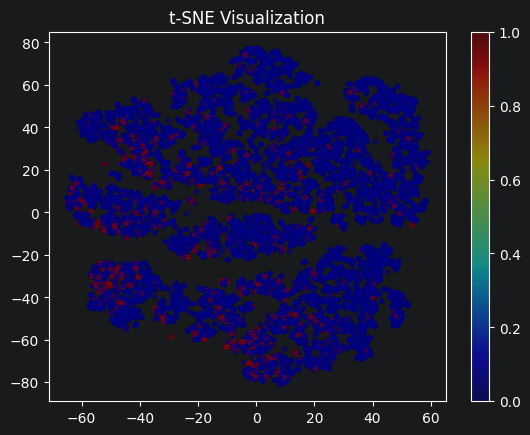

In [33]:
plt.scatter(feat_2D[:, 0], feat_2D[:, 1], c=application_train_df["TARGET"][:10000], cmap='jet', alpha=0.5, s = 10)
plt.colorbar()
plt.title("t-SNE Visualization")
plt.show()

In [40]:
kmeans = KMeans(n_clusters=5)
application_train_df["kmeans_label"] = kmeans.fit_predict(feat_knn_train_df)
application_test_df["kmeans_label"] = kmeans.predict(feat_knn_test_df)
# kmeans.predict(feat_knn_test_df)
application_train_df.head()
print(application_train_df.kmeans_label.value_counts())
print(application_test_df.kmeans_label.value_counts())

kmeans_label
0    99260
2    67172
4    53165
1    52399
3    35515
Name: count, dtype: int64
kmeans_label
2    23132
1     7214
0     6304
3     6175
4     5919
Name: count, dtype: int64


# Save final tables

In [ ]:
save_path = "~/PycharmProjects/home-credit-default-risk/data/processed/"

In [ ]:
application_train_full.to_csv(save_path+"application_train.csv", index=False)

In [ ]:
application_test_full.to_csv(save_path+"application_test.csv", index=False)

In [ ]:
print("Train:", application_train_full.shape)
print("Test:", application_test_full.shape)

In [ ]:
del application_train_full
del application_test_full

gc.collect()